# NLP IAB Real-Time Audience Classification Pipeline — Production ML Pipeline

## End-to-End System: Domain Classification → User Scoring → Audience Segmentation

**Business Context:** In programmatic advertising, audience segments classified by the IAB Content Taxonomy (~700 categories) command **2–5× CPM premiums**. This notebook implements the complete ML pipeline that:

1. **Classifies website domains** into IAB categories using TF-IDF + text classification  
2. **Accumulates per-user IAB affinity scores** from simulated bidstream events  
3. **Applies exponential time-decay** with category-specific half-lives  
4. **Generates audience segments** from decayed user score arrays  
5. **Evaluates** classification quality and segment business metrics  

**Production Design Principles:**
- Every function is parameterized via config dicts — swap the sample data for production Kafka/S3 sources and nothing else changes  
- All thresholds, decay rates, and hyperparameters are centralized in a single config  
- The pipeline is deterministic (seeded randomness) for reproducibility  
- Code is structured as importable modules — cells map 1:1 to pipeline stages

---
## Step 0: Environment Setup & Configuration

We begin by importing all dependencies and defining the **single source of truth** for every tunable parameter in the pipeline. In production, this config would be loaded from a YAML/JSON file or environment variables. Here, it's a Python dict so the notebook is fully self-contained.

**Why centralize config?** When this pipeline moves to Airflow/Prefect, you change `CONFIG` values — not code. Every function reads from this dict, never from magic numbers inline.

In [1]:
# ============================================================================
# IMPORTS — standard library, then third-party, grouped by purpose
# ============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Scikit-learn: text vectorization, classification, evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from scipy.sparse import issparse

# XGBoost: gradient boosting with native sparse matrix support
from xgboost import XGBClassifier

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print("All imports successful.")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"XGBoost: {__import__('xgboost').__version__}")

All imports successful.
NumPy: 2.4.4, Pandas: 3.0.2
Scikit-learn: 1.8.0
XGBoost: 3.2.0


In [2]:
# ============================================================================
# PIPELINE CONFIGURATION — single source of truth for all parameters
# ============================================================================
CONFIG = {
    # --- Data Generation ---
    "n_domains": 2000,              # Number of domains to simulate (production: 200K+)
    "n_users": 5000,                # Number of users (production: 500M+)
    "n_bid_events": 100_000,        # Bidstream events (production: 50B/day)
    "event_window_days": 30,        # How many days of history to simulate

    # --- IAB Taxonomy (subset for demonstration; production uses full ~700) ---
    "iab_tier1_categories": {
        "IAB1":  "Arts & Entertainment",
        "IAB2":  "Automotive",
        "IAB3":  "Business",
        "IAB4":  "Careers",
        "IAB5":  "Education",
        "IAB6":  "Family & Parenting",
        "IAB7":  "Health & Fitness",
        "IAB8":  "Food & Drink",
        "IAB9":  "Hobbies & Interests",
        "IAB10": "Home & Garden",
        "IAB11": "Law, Gov't & Politics",
        "IAB12": "News",
        "IAB13": "Personal Finance",
        "IAB14": "Society",
        "IAB15": "Science",
        "IAB16": "Pets",
        "IAB17": "Sports",
        "IAB18": "Style & Fashion",
        "IAB19": "Technology & Computing",
        "IAB20": "Travel",
        "IAB21": "Real Estate",
        "IAB22": "Shopping",
        "IAB23": "Religion & Spirituality",
    },

    # --- TF-IDF Vectorizer ---
    "tfidf_max_features": 20_000,   # Vocabulary size (production: 50K–100K)
    "tfidf_ngram_range": (1, 2),    # Unigrams + bigrams
    "tfidf_min_df": 2,              # Minimum document frequency
    "tfidf_max_df": 0.95,           # Maximum document frequency
    "tfidf_sublinear_tf": True,     # Apply sublinear TF scaling (1 + log(tf))

    # --- Classifier ---
    "classifier_C": 1.0,            # Logistic Regression regularization
    "classifier_max_iter": 1000,
    "cv_folds": 5,                  # Cross-validation folds
    "classification_threshold": 0.3, # Min probability to assign a category

    # --- Score Decay ---
    # Category-specific half-lives in days: shorter = faster intent decay
    "decay_half_lives": {
        "IAB20": 5,    # Travel — intent decays fast after booking
        "IAB22": 3,    # Shopping — purchase intent is very short-lived
        "IAB2":  7,    # Automotive — research cycle is weeks
        "IAB13": 7,    # Personal Finance — moderate research window
        "IAB5":  30,   # Education — long-term interest
        "IAB19": 14,   # Technology — moderate interest persistence
        "IAB17": 10,   # Sports — seasonal but recurring
        "IAB7":  21,   # Health — ongoing concern
        "_default": 14 # Default half-life for unlisted categories
    },

    # --- Audience Segmentation ---
    "top_k_categories": 5,          # Max categories per user segment
    "segment_score_threshold": 0.5, # Min decayed score to qualify for a segment
    "min_segment_size": 50,         # Min users per segment (production: 1M+)

    # --- Random Seed ---
    "seed": SEED,
}

# Derived: compute lambda from half-lives — lambda = ln(2) / half_life
CONFIG["decay_lambdas"] = {
    cat: np.log(2) / days
    for cat, days in CONFIG["decay_half_lives"].items()
}

print("Configuration loaded.")
print(f"  Domains: {CONFIG['n_domains']:,}")
print(f"  Users: {CONFIG['n_users']:,}")
print(f"  Bid Events: {CONFIG['n_bid_events']:,}")
print(f"  IAB Categories: {len(CONFIG['iab_tier1_categories'])}")
print(f"  Event Window: {CONFIG['event_window_days']} days")

Configuration loaded.
  Domains: 2,000
  Users: 5,000
  Bid Events: 100,000
  IAB Categories: 23
  Event Window: 30 days


---
## Step 1: Synthetic Data Generation — Domain Crawl Corpus

### What we're building
A realistic dataset of **2,000 website domains**, each with:
- A **domain name** (e.g., `techcrunch-247.com`)
- **Crawled text content** — multiple paragraphs of category-specific vocabulary that mimics what a real web crawler would extract
- **Ground-truth IAB labels** — each domain has 1–3 IAB categories (multi-label), reflecting real-world category overlap (e.g., CNN covers News + Politics + Entertainment)

### Why this design
Real domain text has strong topical vocabulary. A travel site uses words like "flights," "hotel," "destination," "itinerary." A finance site uses "investment," "portfolio," "interest rate," "market." Our synthetic generator creates **category-specific vocabulary pools** and composes domain text by sampling from them — including deliberate cross-category bleed to test the classifier's ability to handle ambiguity.

### Production equivalent
In production, this data comes from a **Scrapy crawl pipeline** that fetches 3–5 pages per domain from 200K+ curated domains bi-weekly. The crawled HTML is stripped to clean text via readability extractors. Here we simulate that output directly.

In [3]:
# ============================================================================
# CATEGORY VOCABULARY POOLS
# Each category gets a curated set of terms that a real website in that
# category would contain. These drive the TF-IDF signal.
# ============================================================================

CATEGORY_VOCAB = {
    "IAB1": [  # Arts & Entertainment
        "movie", "film", "cinema", "actor", "actress", "director", "screenplay",
        "theater", "performance", "comedy", "drama", "concert", "music", "album",
        "artist", "gallery", "exhibition", "painting", "sculpture", "streaming",
        "entertainment", "celebrity", "awards", "oscar", "grammy", "box office",
        "ticket", "premiere", "soundtrack", "animation", "documentary", "series",
        "broadway", "festival", "review", "critics", "audience", "blockbuster",
        "indie film", "binge watch", "episode", "season finale", "cast", "plot"
    ],
    "IAB2": [  # Automotive
        "car", "vehicle", "automobile", "engine", "horsepower", "torque", "sedan",
        "SUV", "truck", "electric vehicle", "EV", "hybrid", "fuel efficiency",
        "miles per gallon", "mpg", "dealership", "test drive", "acceleration",
        "braking", "suspension", "transmission", "automatic", "manual", "turbo",
        "diesel", "gasoline", "battery range", "charging station", "autonomous",
        "self driving", "safety rating", "crash test", "recall", "model year",
        "lease", "financing", "trade in", "mileage", "odometer", "tire", "brake"
    ],
    "IAB3": [  # Business
        "company", "corporation", "revenue", "profit", "market share", "CEO",
        "executive", "board of directors", "quarterly earnings", "fiscal year",
        "startup", "venture capital", "IPO", "merger", "acquisition", "strategy",
        "management", "leadership", "enterprise", "B2B", "supply chain",
        "logistics", "operations", "consulting", "productivity", "efficiency",
        "stakeholder", "shareholder", "dividend", "corporate", "business model",
        "scalability", "growth", "market expansion", "competitive advantage",
        "disruption", "innovation", "workforce", "employee", "organizational"
    ],
    "IAB4": [  # Careers
        "job", "career", "resume", "interview", "hiring", "recruitment",
        "salary", "compensation", "benefits", "remote work", "freelance",
        "promotion", "skills", "professional development", "networking",
        "LinkedIn", "job search", "employer", "employee", "workplace",
        "career change", "internship", "apprenticeship", "mentorship",
        "work life balance", "unemployment", "job market", "talent",
        "headhunter", "recruiter", "cover letter", "reference", "onboarding"
    ],
    "IAB5": [  # Education
        "school", "university", "college", "student", "teacher", "professor",
        "curriculum", "course", "degree", "diploma", "scholarship", "tuition",
        "classroom", "lecture", "textbook", "exam", "grade", "GPA", "enrollment",
        "online learning", "e-learning", "MOOC", "certification", "training",
        "academic", "research", "thesis", "dissertation", "campus", "alumni",
        "graduate", "undergraduate", "STEM", "liberal arts", "continuing education",
        "pedagogy", "literacy", "educational technology", "learning management"
    ],
    "IAB6": [  # Family & Parenting
        "parenting", "child", "baby", "toddler", "newborn", "pregnancy",
        "family", "mother", "father", "parent", "childcare", "daycare",
        "school age", "teenager", "adolescent", "discipline", "bedtime",
        "breastfeeding", "formula", "stroller", "diaper", "nursery",
        "play date", "family vacation", "sibling", "adoption", "foster care",
        "pediatrician", "vaccination", "milestone", "development", "maternity"
    ],
    "IAB7": [  # Health & Fitness
        "health", "fitness", "exercise", "workout", "gym", "nutrition", "diet",
        "calories", "protein", "vitamin", "supplement", "wellness", "yoga",
        "meditation", "mental health", "therapy", "doctor", "hospital",
        "medical", "diagnosis", "treatment", "prescription", "symptom",
        "disease", "prevention", "weight loss", "muscle", "cardio", "strength",
        "running", "marathon", "BMI", "blood pressure", "cholesterol", "immune",
        "sleep", "recovery", "physical therapy", "healthcare", "clinic"
    ],
    "IAB8": [  # Food & Drink
        "recipe", "cooking", "kitchen", "ingredient", "meal", "dinner",
        "breakfast", "lunch", "restaurant", "chef", "cuisine", "baking",
        "dessert", "appetizer", "entree", "vegan", "vegetarian", "organic",
        "gluten free", "food", "drink", "wine", "beer", "cocktail", "coffee",
        "tea", "nutrition", "calories", "food delivery", "takeout", "menu",
        "seasoning", "spice", "grill", "oven", "slow cooker", "meal prep"
    ],
    "IAB9": [  # Hobbies & Interests
        "hobby", "craft", "DIY", "woodworking", "knitting", "sewing",
        "gardening", "photography", "painting", "drawing", "model building",
        "collecting", "stamps", "coins", "board game", "puzzle", "fishing",
        "hunting", "camping", "hiking", "bird watching", "astronomy",
        "amateur radio", "drone", "RC car", "miniature", "scrapbooking",
        "calligraphy", "pottery", "ceramics", "quilting", "origami"
    ],
    "IAB10": [  # Home & Garden
        "home improvement", "renovation", "remodeling", "interior design",
        "furniture", "decor", "landscaping", "lawn", "garden", "plumbing",
        "electrical", "roofing", "flooring", "paint", "wallpaper", "kitchen",
        "bathroom", "bedroom", "living room", "patio", "deck", "fence",
        "appliance", "HVAC", "insulation", "contractor", "blueprint", "permit",
        "curb appeal", "property value", "smart home", "lighting", "storage"
    ],
    "IAB11": [  # Law, Gov't & Politics
        "law", "legal", "court", "judge", "attorney", "lawyer", "legislation",
        "regulation", "policy", "government", "congress", "senate", "election",
        "vote", "campaign", "democrat", "republican", "political", "bill",
        "amendment", "constitution", "rights", "justice", "supreme court",
        "lobbying", "advocacy", "public policy", "federal", "state", "municipal",
        "executive order", "referendum", "ballot", "partisan", "bipartisan"
    ],
    "IAB12": [  # News
        "breaking news", "headline", "reporter", "journalist", "press",
        "media", "broadcast", "editorial", "opinion", "investigation",
        "source", "correspondent", "anchor", "coverage", "update", "alert",
        "developing story", "exclusive", "press conference", "briefing",
        "news wire", "AP", "Reuters", "live coverage", "current events",
        "world news", "national news", "local news", "newsroom", "deadline"
    ],
    "IAB13": [  # Personal Finance
        "investment", "stock", "bond", "mutual fund", "ETF", "portfolio",
        "retirement", "401k", "IRA", "savings", "interest rate", "mortgage",
        "credit card", "debt", "loan", "budget", "financial planning",
        "wealth management", "tax", "insurance", "banking", "compound interest",
        "inflation", "dividend", "capital gains", "asset allocation", "risk",
        "credit score", "FICO", "refinance", "down payment", "APR", "yield"
    ],
    "IAB14": [  # Society
        "community", "culture", "social", "diversity", "inclusion", "equality",
        "civil rights", "human rights", "charity", "nonprofit", "volunteer",
        "philanthropy", "social justice", "activism", "protest", "movement",
        "demographic", "population", "immigration", "refugee", "urban",
        "rural", "poverty", "inequality", "social media", "identity"
    ],
    "IAB15": [  # Science
        "research", "scientist", "experiment", "laboratory", "hypothesis",
        "theory", "data", "peer review", "journal", "discovery", "physics",
        "chemistry", "biology", "astronomy", "geology", "climate", "DNA",
        "genome", "molecule", "atom", "quantum", "space", "NASA", "telescope",
        "particle", "evolution", "ecology", "neuroscience", "vaccine", "study"
    ],
    "IAB16": [  # Pets
        "dog", "cat", "pet", "puppy", "kitten", "breed", "veterinarian",
        "vet", "animal", "pet food", "grooming", "training", "obedience",
        "leash", "collar", "cage", "aquarium", "fish", "bird", "hamster",
        "rabbit", "reptile", "adoption", "shelter", "rescue", "spay",
        "neuter", "vaccination", "flea", "tick", "heartworm", "pet insurance"
    ],
    "IAB17": [  # Sports
        "football", "basketball", "baseball", "soccer", "tennis", "golf",
        "hockey", "cricket", "rugby", "swimming", "athletics", "Olympics",
        "championship", "tournament", "league", "team", "player", "coach",
        "score", "goal", "touchdown", "home run", "MVP", "draft", "trade",
        "season", "playoffs", "final", "stadium", "fan", "ESPN", "highlight",
        "referee", "penalty", "foul", "injury", "transfer", "contract"
    ],
    "IAB18": [  # Style & Fashion
        "fashion", "style", "clothing", "outfit", "trend", "designer",
        "runway", "collection", "couture", "accessory", "jewelry", "handbag",
        "shoes", "sneakers", "dress", "suit", "casual", "formal", "brand",
        "luxury", "vintage", "thrift", "sustainable fashion", "textile",
        "fabric", "pattern", "wardrobe", "makeup", "beauty", "skincare",
        "cosmetics", "fragrance", "perfume", "nail", "hairstyle", "salon"
    ],
    "IAB19": [  # Technology & Computing
        "technology", "software", "hardware", "computer", "laptop", "smartphone",
        "tablet", "processor", "GPU", "RAM", "storage", "cloud computing",
        "AI", "artificial intelligence", "machine learning", "data science",
        "programming", "developer", "code", "algorithm", "database", "API",
        "cybersecurity", "encryption", "blockchain", "startup", "Silicon Valley",
        "app", "mobile", "iOS", "Android", "operating system", "Linux",
        "open source", "SaaS", "DevOps", "microservice", "server", "network"
    ],
    "IAB20": [  # Travel
        "travel", "flight", "hotel", "resort", "vacation", "destination",
        "itinerary", "booking", "airline", "airport", "passport", "visa",
        "luggage", "backpacking", "cruise", "tour", "sightseeing", "beach",
        "mountain", "adventure", "road trip", "accommodation", "hostel",
        "Airbnb", "travel insurance", "jet lag", "layover", "connecting flight",
        "tourist", "attraction", "landmark", "excursion", "all inclusive",
        "travel guide", "wanderlust", "expedition", "safari", "tropical"
    ],
    "IAB21": [  # Real Estate
        "real estate", "property", "house", "apartment", "condo", "mortgage",
        "listing", "MLS", "realtor", "agent", "broker", "buyer", "seller",
        "closing", "escrow", "appraisal", "inspection", "zoning", "HOA",
        "square footage", "bedroom", "bathroom", "kitchen", "open house",
        "offer", "counter offer", "bidding war", "foreclosure", "rental",
        "lease", "tenant", "landlord", "property management", "investment property"
    ],
    "IAB22": [  # Shopping
        "shopping", "deal", "discount", "coupon", "sale", "clearance",
        "price", "comparison", "review", "rating", "product", "brand",
        "online shopping", "e-commerce", "cart", "checkout", "shipping",
        "delivery", "return", "refund", "warranty", "gift", "wish list",
        "Black Friday", "Cyber Monday", "Prime Day", "flash sale", "promo code",
        "free shipping", "buy one get one", "bargain", "wholesale", "retail"
    ],
    "IAB23": [  # Religion & Spirituality
        "religion", "faith", "spiritual", "prayer", "worship", "church",
        "mosque", "temple", "synagogue", "Bible", "Quran", "Torah",
        "meditation", "mindfulness", "soul", "divine", "sacred", "holy",
        "sermon", "congregation", "clergy", "pastor", "imam", "rabbi",
        "pilgrimage", "ritual", "ceremony", "blessing", "scripture", "belief"
    ],
}

print(f"Vocabulary pools defined for {len(CATEGORY_VOCAB)} IAB categories.")
print(f"Average terms per category: {np.mean([len(v) for v in CATEGORY_VOCAB.values()]):.0f}")

Vocabulary pools defined for 23 IAB categories.
Average terms per category: 35


In [4]:
# ============================================================================
# DOMAIN DATA GENERATOR
# Generates realistic synthetic domain crawl data with multi-label IAB tags.
# Each domain's text is composed primarily from its assigned categories'
# vocabulary, with controlled noise from other categories to simulate
# real-world topic overlap.
# ============================================================================

def generate_domain_corpus(config: dict, vocab: dict, seed: int = 42) -> pd.DataFrame:
    """
    Generate a synthetic domain crawl corpus.

    For each domain:
      1. Assign 1-3 primary IAB categories (weighted by real-world prevalence)
      2. Build text by sampling 60-150 terms from primary categories (80%)
         plus noise terms from random other categories (20%)
      3. Compose into paragraph-like text with repetition for TF-IDF signal

    Returns:
        DataFrame with columns: [domain, text, iab_categories, primary_category]
    """
    rng = np.random.RandomState(seed)
    categories = list(vocab.keys())
    n_domains = config["n_domains"]

    # Category prevalence weights — News, Tech, Entertainment are more common
    prevalence = {
        "IAB1": 1.5, "IAB2": 0.8, "IAB3": 1.2, "IAB4": 0.6, "IAB5": 1.0,
        "IAB6": 0.7, "IAB7": 1.3, "IAB8": 1.1, "IAB9": 0.5, "IAB10": 0.6,
        "IAB11": 0.8, "IAB12": 1.5, "IAB13": 1.0, "IAB14": 0.5, "IAB15": 0.7,
        "IAB16": 0.4, "IAB17": 1.4, "IAB18": 0.9, "IAB19": 1.6, "IAB20": 1.2,
        "IAB21": 0.7, "IAB22": 1.3, "IAB23": 0.3,
    }
    weights = np.array([prevalence.get(c, 1.0) for c in categories])
    weights /= weights.sum()

    # Domain name prefixes for realism
    prefixes = [
        "daily", "the", "best", "top", "my", "all", "go", "pro", "smart",
        "fast", "new", "global", "digital", "online", "hub", "central",
        "insider", "expert", "prime", "elite", "mega", "ultra", "super",
        "net", "web", "info", "guide", "world", "zone", "spot"
    ]
    suffixes = [".com", ".net", ".org", ".io", ".co"]
    category_slugs = {
        "IAB1": "entertainment", "IAB2": "auto", "IAB3": "business",
        "IAB4": "careers", "IAB5": "edu", "IAB6": "family",
        "IAB7": "health", "IAB8": "food", "IAB9": "hobbies",
        "IAB10": "home", "IAB11": "politics", "IAB12": "news",
        "IAB13": "finance", "IAB14": "society", "IAB15": "science",
        "IAB16": "pets", "IAB17": "sports", "IAB18": "fashion",
        "IAB19": "tech", "IAB20": "travel", "IAB21": "realestate",
        "IAB22": "shopping", "IAB23": "faith",
    }

    records = []
    used_domains = set()

    for i in range(n_domains):
        # Assign 1-3 categories (70% get 1, 20% get 2, 10% get 3)
        n_cats = rng.choice([1, 2, 3], p=[0.70, 0.20, 0.10])
        assigned_cats = list(rng.choice(categories, size=n_cats, replace=False, p=weights))
        primary_cat = assigned_cats[0]

        # Generate unique domain name
        slug = category_slugs.get(primary_cat, "site")
        while True:
            prefix = rng.choice(prefixes)
            suffix = rng.choice(suffixes)
            domain = f"{prefix}-{slug}-{rng.randint(1, 9999)}{suffix}"
            if domain not in used_domains:
                used_domains.add(domain)
                break

        # Build text content
        n_terms = rng.randint(60, 150)
        n_primary = int(n_terms * 0.80)
        n_noise = n_terms - n_primary

        # Primary category terms (with repetition for TF-IDF boost)
        primary_terms = []
        for cat in assigned_cats:
            cat_terms = vocab[cat]
            share = n_primary // len(assigned_cats)
            sampled = rng.choice(cat_terms, size=share, replace=True).tolist()
            primary_terms.extend(sampled)

        # Noise terms from random other categories
        noise_cats = [c for c in categories if c not in assigned_cats]
        noise_cat = rng.choice(noise_cats)
        noise_terms = rng.choice(vocab[noise_cat], size=n_noise, replace=True).tolist()

        all_terms = primary_terms + noise_terms
        rng.shuffle(all_terms)
        text = " ".join(all_terms)

        records.append({
            "domain": domain,
            "text": text,
            "iab_categories": assigned_cats,
            "primary_category": primary_cat,
        })

    df = pd.DataFrame(records)
    return df


# Generate the corpus
domain_df = generate_domain_corpus(CONFIG, CATEGORY_VOCAB, seed=SEED)

print(f"Generated {len(domain_df):,} domains")
print(f"\nCategory distribution (primary):")
print(domain_df["primary_category"].value_counts().head(10).to_string())
print(f"\nMulti-label distribution:")
print(domain_df["iab_categories"].apply(len).value_counts().sort_index().to_string())
print(f"\nSample domain:")
sample = domain_df.iloc[0]
print(f"  Domain:     {sample['domain']}")
print(f"  Categories: {sample['iab_categories']}")
print(f"  Text (first 200 chars): {sample['text'][:200]}...")

Generated 2,000 domains

Category distribution (primary):
primary_category
IAB17    147
IAB1     134
IAB19    132
IAB12    130
IAB7     119
IAB22    117
IAB20    112
IAB3     108
IAB13    105
IAB8      96

Multi-label distribution:
iab_categories
1    1393
2     406
3     201

Sample domain:
  Domain:     new-shopping-5735.co
  Categories: [np.str_('IAB22')]
  Text (first 200 chars): coupon promo code brand retail free shipping referendum deal Prime Day gift review promo code buy one get one online shopping cart lawyer legal comparison referendum retail wish list refund public pol...


### Visualize the Domain Corpus

Before modeling, we inspect the data distribution. In production, this would be a monitoring dashboard showing:
- **Category balance** — are we under-sampling any IAB category?
- **Text length distribution** — do all domains have enough text for meaningful TF-IDF features?
- **Multi-label frequency** — how many domains span multiple categories?

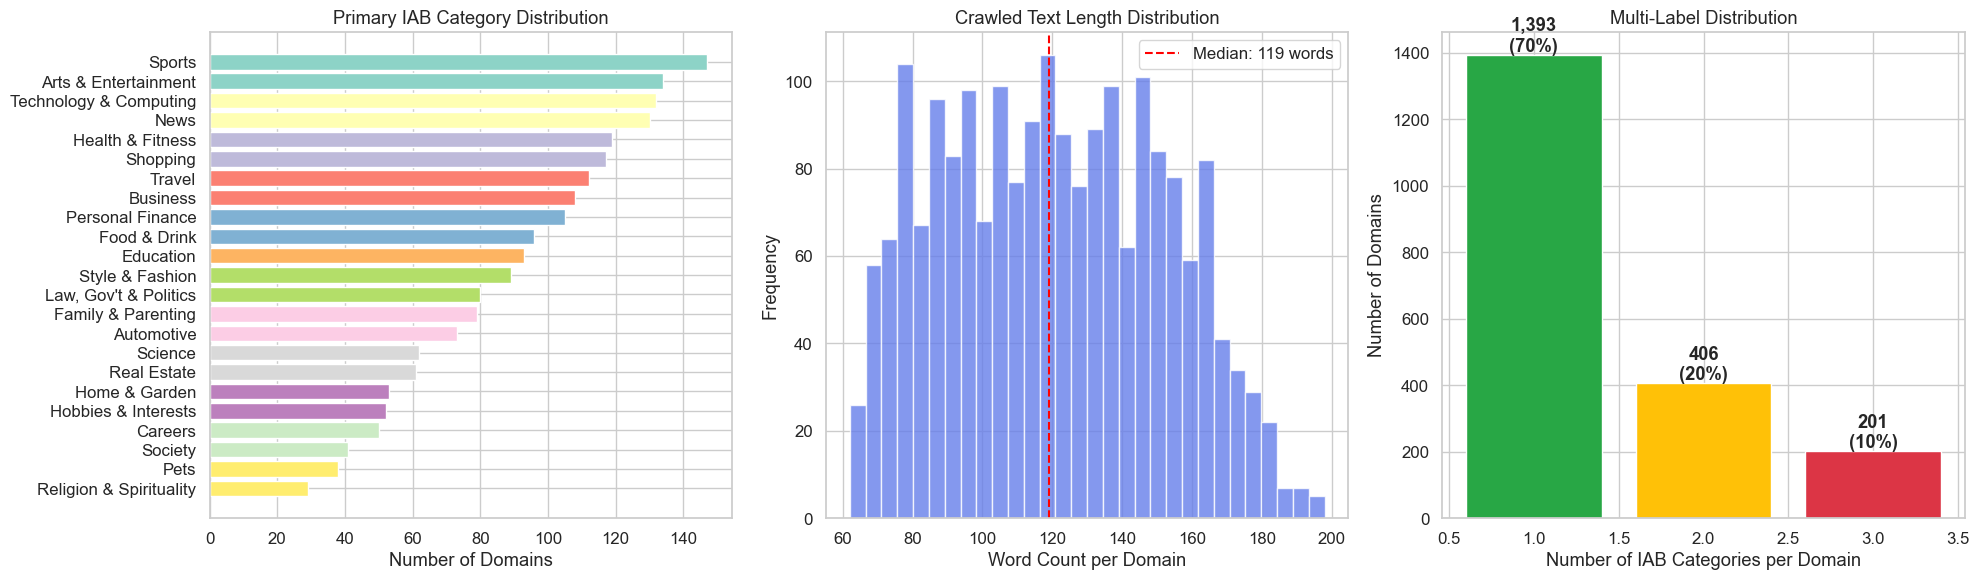


Corpus Summary Statistics:
  Total domains:        2,000
  Unique categories:    23
  Avg words per domain: 120.2
  Min / Max words:      62 / 198
  Multi-label domains:  607 (30.3%)


In [5]:
# ============================================================================
# DOMAIN CORPUS VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Primary category distribution
cat_counts = domain_df["primary_category"].value_counts()
cat_names = [CONFIG["iab_tier1_categories"].get(c, c) for c in cat_counts.index]
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
axes[0].barh(cat_names, cat_counts.values, color=colors)
axes[0].set_xlabel("Number of Domains")
axes[0].set_title("Primary IAB Category Distribution")
axes[0].invert_yaxis()

# 2. Text length distribution (word count)
domain_df["word_count"] = domain_df["text"].str.split().str.len()
axes[1].hist(domain_df["word_count"], bins=30, color="#667eea", edgecolor="white", alpha=0.8)
axes[1].axvline(domain_df["word_count"].median(), color="red", linestyle="--",
                label=f"Median: {domain_df['word_count'].median():.0f} words")
axes[1].set_xlabel("Word Count per Domain")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Crawled Text Length Distribution")
axes[1].legend()

# 3. Multi-label frequency
label_counts = domain_df["iab_categories"].apply(len).value_counts().sort_index()
axes[2].bar(label_counts.index, label_counts.values, color=["#28a745", "#ffc107", "#dc3545"])
axes[2].set_xlabel("Number of IAB Categories per Domain")
axes[2].set_ylabel("Number of Domains")
axes[2].set_title("Multi-Label Distribution")
for i, (x, y) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[2].text(x, y + 10, f"{y:,}\n({y/len(domain_df)*100:.0f}%)",
                 ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/01_domain_corpus_overview.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorpus Summary Statistics:")
print(f"  Total domains:        {len(domain_df):,}")
print(f"  Unique categories:    {domain_df['primary_category'].nunique()}")
print(f"  Avg words per domain: {domain_df['word_count'].mean():.1f}")
print(f"  Min / Max words:      {domain_df['word_count'].min()} / {domain_df['word_count'].max()}")
print(f"  Multi-label domains:  {(domain_df['iab_categories'].apply(len) > 1).sum():,} "
      f"({(domain_df['iab_categories'].apply(len) > 1).mean()*100:.1f}%)")

---
## Step 2: TF-IDF Feature Engineering

### What TF-IDF does and why we chose it

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts raw text into numerical feature vectors by measuring how important each word is to a document relative to the entire corpus.

**The formula:**

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Where:
- **TF(t, d)** = frequency of term `t` in document `d` (we use sublinear: `1 + log(tf)`)
- **IDF(t)** = `log(N / df(t))` where `N` = total documents, `df(t)` = documents containing `t`

### Why TF-IDF over embeddings (Word2Vec, BERT)?

| Criterion | TF-IDF | Word Embeddings | BERT/Transformers |
|-----------|--------|-----------------|-------------------|
| **Latency** | <1ms vectorization | ~5ms | ~50-100ms |
| **Interpretability** | Direct word→weight mapping | Opaque dimensions | Black box |
| **Training data needed** | Works with 1K+ docs | Needs 100K+ | Needs fine-tuning data |
| **Domain vocabulary** | Excellent for specialized terms | May miss rare terms | Good if fine-tuned |
| **Production simplicity** | Serializable, no GPU | Needs embedding lookup | Needs GPU serving |

**Decision:** TF-IDF wins for our domain classification use case because:
1. Domain text is **keyword-rich** — travel sites say "flight," "hotel," "booking" repeatedly
2. We need **sub-5ms inference** on the domain lookup table refresh path
3. We have 200K domains — enough for good IDF statistics but not enough to train embeddings from scratch
4. **Interpretability matters** — when a domain is misclassified, we can inspect which words drove the decision

In [6]:
# ============================================================================
# TF-IDF VECTORIZATION
# Fit on the full domain corpus. In production, this vectorizer is serialized
# (via joblib) and loaded by the batch classification pipeline.
# ============================================================================

tfidf_vectorizer = TfidfVectorizer(
    max_features=CONFIG["tfidf_max_features"],
    ngram_range=CONFIG["tfidf_ngram_range"],
    min_df=CONFIG["tfidf_min_df"],
    max_df=CONFIG["tfidf_max_df"],
    sublinear_tf=CONFIG["tfidf_sublinear_tf"],
    strip_accents="unicode",
    token_pattern=r"(?u)\b\w[\w'-]*\w\b|\b\w\b",  # handles hyphenated terms and single chars
)

# Fit and transform the corpus
X_tfidf = tfidf_vectorizer.fit_transform(domain_df["text"])

feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"  Documents (domains):  {X_tfidf.shape[0]:,}")
print(f"  Features (vocab size): {X_tfidf.shape[1]:,}")
print(f"  Non-zero entries:      {X_tfidf.nnz:,}")
print(f"  Sparsity:              {(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))*100:.2f}%")
print(f"  Memory (sparse):       {X_tfidf.data.nbytes / 1024 / 1024:.2f} MB")
print(f"\nSample feature names (first 20): {list(feature_names[:20])}")
print(f"Sample feature names (last 20):  {list(feature_names[-20:])}")

TF-IDF Matrix Shape: (2000, 20000)
  Documents (domains):  2,000
  Features (vocab size): 20,000
  Non-zero entries:      236,436
  Sparsity:              99.41%
  Memory (sparse):       1.80 MB

Sample feature names (first 20): ['401k', '401k 401k', '401k apr', '401k asset', '401k banking', '401k bond', '401k budget', '401k capital', '401k compound', '401k credit', '401k dividend', '401k etf', '401k family', '401k fico', '401k financial', '401k inflation', '401k insurance', '401k interest', '401k investment', '401k ira']
Sample feature names (last 20):  ['zoning bathroom', 'zoning bedroom', 'zoning buyer', 'zoning closing', 'zoning escrow', 'zoning hoa', 'zoning house', 'zoning kitchen', 'zoning landlord', 'zoning lease', 'zoning listing', 'zoning mls', 'zoning mortgage', 'zoning offer', 'zoning open', 'zoning property', 'zoning realtor', 'zoning rental', 'zoning seller', 'zoning square']


### TF-IDF Worked Example

Let's trace exactly how TF-IDF scores a single domain. This is the kind of debugging you'd do in production when a domain is misclassified — inspect which terms drove the prediction.

Domain: new-shopping-5735.co
Ground Truth Categories: [np.str_('IAB22')]
  → ['Shopping']

Non-zero features: 163 out of 20000

Top 20 TF-IDF Features (these drive the classification):
Rank  Term                       TF-IDF Score
---------------------------------------------
   1  comparison e-commerce            0.1236
   2  review price                     0.1236
   3  black                            0.1159
   4  friday                           0.1159
   5  black friday                     0.1159
   6  deal prime                       0.1144
   7  cart                             0.1104
   8  one                              0.1087
   9  promo                            0.1082
  10  promo code                       0.1082
  11  e-commerce                       0.1080
  12  price                            0.1057
  13  deal                             0.1030
  14  shopping                         0.1016
  15  prime                            0.1004
  16  day                        

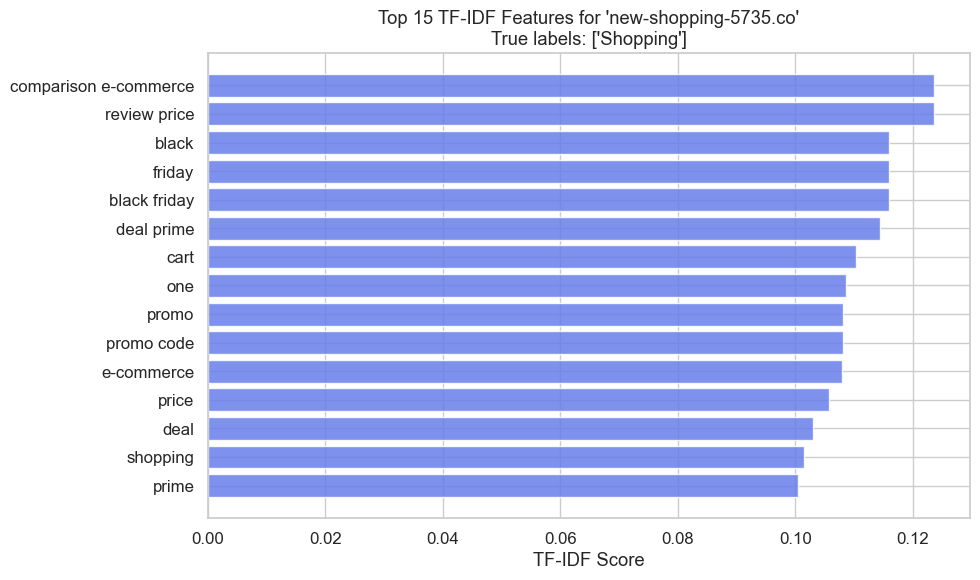

In [7]:
# ============================================================================
# TF-IDF WORKED EXAMPLE — inspect one domain's feature vector
# ============================================================================

example_idx = 0
example_domain = domain_df.iloc[example_idx]
example_vector = X_tfidf[example_idx]

# Extract non-zero features and sort by TF-IDF weight
nonzero_indices = example_vector.nonzero()[1]
tfidf_scores = example_vector.toarray().flatten()
top_features = sorted(
    [(feature_names[i], tfidf_scores[i]) for i in nonzero_indices],
    key=lambda x: -x[1]
)

print(f"Domain: {example_domain['domain']}")
print(f"Ground Truth Categories: {example_domain['iab_categories']}")
print(f"  → {[CONFIG['iab_tier1_categories'][c] for c in example_domain['iab_categories']]}")
print(f"\nNon-zero features: {len(nonzero_indices)} out of {X_tfidf.shape[1]}")
print(f"\nTop 20 TF-IDF Features (these drive the classification):")
print(f"{'Rank':>4}  {'Term':<25}  {'TF-IDF Score':>12}")
print("-" * 45)
for rank, (term, score) in enumerate(top_features[:20], 1):
    print(f"{rank:>4}  {term:<25}  {score:>12.4f}")

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
terms = [t for t, s in top_features[:15]]
scores = [s for t, s in top_features[:15]]
bars = ax.barh(terms[::-1], scores[::-1], color="#667eea", alpha=0.85)
ax.set_xlabel("TF-IDF Score")
ax.set_title(f"Top 15 TF-IDF Features for '{example_domain['domain']}'\n"
             f"True labels: {[CONFIG['iab_tier1_categories'][c] for c in example_domain['iab_categories']]}")
plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/02_tfidf_worked_example.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Step 3: Domain Classification Model — Training & Evaluation

### Model Architecture

We use **OneVsRest Logistic Regression** with probability calibration. This approach:

1. **Trains one binary classifier per IAB category** — each classifier learns "is this domain about Travel? yes/no"
2. **Outputs calibrated probabilities** — not just binary labels, but P(IAB20|domain_text) = 0.82
3. **Handles multi-label natively** — a domain can score high on multiple categories simultaneously

### Why Logistic Regression over tree-based models?

| Factor | Logistic Regression | Random Forest | XGBoost | SGD Classifier |
|--------|-------------------|---------------|---------|----------------|
| **Sparse input handling** | Native — works directly on sparse TF-IDF matrices | Must densify or use specific implementations | Native sparse support via `tree_method='hist'` | Native sparse support |
| **Calibrated probabilities** | Well-calibrated with Platt scaling | Poorly calibrated (bagging effect) | Moderate — better than RF, but post-hoc calibration still helps | Needs calibration |
| **Training time (200K docs)** | ~2 minutes | ~15 minutes | ~5–10 minutes | ~1 minute |
| **Prediction time** | ~0.1ms/doc | ~5ms/doc | ~1ms/doc | ~0.1ms/doc |
| **Interpretability** | Coefficient → word importance | Feature importance only | gain/cover importance + SHAP | Coefficient-based |
| **Overfitting risk** | Low (L2 regularization) | Low (bagging) | Moderate (needs early stopping / depth limits) | Low (regularization) |

We train all four and compare. XGBoost is included because it is the industry standard for tabular/sparse classification tasks and often achieves strong F1 on imbalanced multi-label problems. Logistic Regression remains our production pick for its calibration quality and sub-millisecond latency.

In [8]:
# ============================================================================
# LABEL ENCODING — convert multi-label lists to binary matrix
# ============================================================================

mlb = MultiLabelBinarizer(classes=sorted(CONFIG["iab_tier1_categories"].keys()))
Y_binary = mlb.fit_transform(domain_df["iab_categories"])

print(f"Label matrix shape: {Y_binary.shape}")
print(f"  Domains: {Y_binary.shape[0]:,}")
print(f"  Categories: {Y_binary.shape[1]}")
print(f"  Total positive labels: {Y_binary.sum():,.0f}")
print(f"  Avg labels per domain: {Y_binary.sum(axis=1).mean():.2f}")
print(f"\nLabel frequency per category:")
label_freq = pd.DataFrame({
    "Category": mlb.classes_,
    "Name": [CONFIG["iab_tier1_categories"][c] for c in mlb.classes_],
    "Positive Count": Y_binary.sum(axis=0).astype(int),
    "Prevalence %": (Y_binary.mean(axis=0) * 100).round(2)
}).sort_values("Positive Count", ascending=False)
print(label_freq.to_string(index=False))

Label matrix shape: (2000, 23)
  Domains: 2,000
  Categories: 23
  Total positive labels: 2,808
  Avg labels per domain: 1.40

Label frequency per category:
Category                    Name  Positive Count  Prevalence %
    IAB1    Arts & Entertainment             201         10.05
   IAB17                  Sports             195          9.75
   IAB12                    News             187          9.35
   IAB19  Technology & Computing             172          8.60
    IAB7        Health & Fitness             166          8.30
   IAB22                Shopping             163          8.15
    IAB3                Business             156          7.80
   IAB20                  Travel             156          7.80
   IAB13        Personal Finance             143          7.15
    IAB8            Food & Drink             135          6.75
   IAB18         Style & Fashion             126          6.30
    IAB5               Education             124          6.20
    IAB6      Family & P

### Model Comparison: Train 3 classifiers and compare via cross-validation

We train each model using **5-fold stratified cross-validation** on the primary label. This gives us out-of-fold predictions for every domain — a robust estimate of generalization performance without a separate holdout set (important when categories like IAB23 have few examples).

In [9]:
# ============================================================================
# MODEL COMPARISON — Logistic Regression vs SGD vs Random Forest vs XGBoost
# Using cross-validation on primary_category for stratification.
# We evaluate on the full multi-label target matrix.
# ============================================================================
import time

# Encode primary_category for stratified CV
le = LabelEncoder()
y_primary_encoded = le.fit_transform(domain_df["primary_category"])

cv = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=SEED)

models = {
    "Logistic Regression (L2)": OneVsRestClassifier(
        LogisticRegression(C=CONFIG["classifier_C"], max_iter=CONFIG["classifier_max_iter"],
                           solver="lbfgs", random_state=SEED),
        n_jobs=-1
    ),
    "SGD (Log Loss + L2)": OneVsRestClassifier(
        SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=1000, random_state=SEED),
        n_jobs=-1
    ),
    "Random Forest": OneVsRestClassifier(
        RandomForestClassifier(n_estimators=100, max_depth=20, random_state=SEED, n_jobs=-1),
        n_jobs=-1
    ),
    "XGBoost": OneVsRestClassifier(
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            tree_method="hist",       # native sparse matrix support
            eval_metric="logloss",
            use_label_encoder=False,
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        ),
        n_jobs=-1
    ),
}

results = {}

for name, model in models.items():
    print(f"\nTraining: {name}")
    start_time = time.time()

    # Cross-validated probability predictions
    y_scores = np.zeros_like(Y_binary, dtype=float)

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_tfidf, y_primary_encoded)):
        X_train_fold = X_tfidf[train_idx]
        Y_train_fold = Y_binary[train_idx]
        X_val_fold = X_tfidf[val_idx]

        model.fit(X_train_fold, Y_train_fold)

        if hasattr(model, "predict_proba"):
            y_scores[val_idx] = model.predict_proba(X_val_fold)
        else:
            y_scores[val_idx] = model.decision_function(X_val_fold)

        print(f"  Fold {fold_idx + 1}/{CONFIG['cv_folds']} complete")

    elapsed = time.time() - start_time

    # Threshold probabilities to get binary predictions
    y_pred = (y_scores >= CONFIG["classification_threshold"]).astype(int)

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        Y_binary, y_pred, average="macro", zero_division=0
    )

    # Per-category AUC (only for categories with both positive and negative examples)
    aucs = []
    for i in range(Y_binary.shape[1]):
        if Y_binary[:, i].sum() > 0 and Y_binary[:, i].sum() < len(Y_binary):
            aucs.append(roc_auc_score(Y_binary[:, i], y_scores[:, i]))
    mean_auc = np.mean(aucs) if aucs else 0.0

    results[name] = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_auc": mean_auc,
        "train_time": elapsed,
        "y_scores": y_scores,
        "y_pred": y_pred,
    }

    print(f"  Time: {elapsed:.1f}s | Precision: {precision:.4f} | "
          f"Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {mean_auc:.4f}")

# Summary comparison table
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
comparison_df = pd.DataFrame({
    name: {
        "Macro Precision": f"{r['precision']:.4f}",
        "Macro Recall": f"{r['recall']:.4f}",
        "Macro F1": f"{r['f1']:.4f}",
        "Mean AUC": f"{r['mean_auc']:.4f}",
        "Training Time (s)": f"{r['train_time']:.1f}",
    }
    for name, r in results.items()
}).T
print(comparison_df.to_string())


Training: Logistic Regression (L2)


  Fold 1/5 complete
  Fold 2/5 complete


  Fold 3/5 complete
  Fold 4/5 complete


  Fold 5/5 complete
  Time: 3.0s | Precision: 0.9957 | Recall: 0.8004 | F1: 0.8827 | AUC: 0.9996

Training: SGD (Log Loss + L2)
  Fold 1/5 complete


  Fold 2/5 complete
  Fold 3/5 complete


...

  Fold 1/5 complete


  Fold 2/5 complete


  Fold 3/5 complete


  Fold 4/5 complete


  Fold 5/5 complete
  Time: 14.2s | Precision: 0.8999 | Recall: 0.9163 | F1: 0.9075 | AUC: 0.9984

MODEL COMPARISON SUMMARY
                         Macro Precision Macro Recall Macro F1 Mean AUC Training Time (s)
Logistic Regression (L2)          0.9957       0.8004   0.8827   0.9996               3.0
SGD (Log Loss + L2)               0.9612       0.9063   0.9309   0.9990               0.7
Random Forest                     0.7827       0.9827   0.8679   0.9993               4.0
XGBoost                           0.8999       0.9163   0.9075   0.9984              14.2


### Visualize Model Comparison

We compare models on four axes that matter for production:
1. **F1 Score** — balance of precision and recall per category
2. **AUC** — ranking quality (can we separate positive from negative domains?)
3. **Training time** — how long until we can refresh the domain lookup table?
4. **Per-category performance** — which IAB categories are hardest to classify?

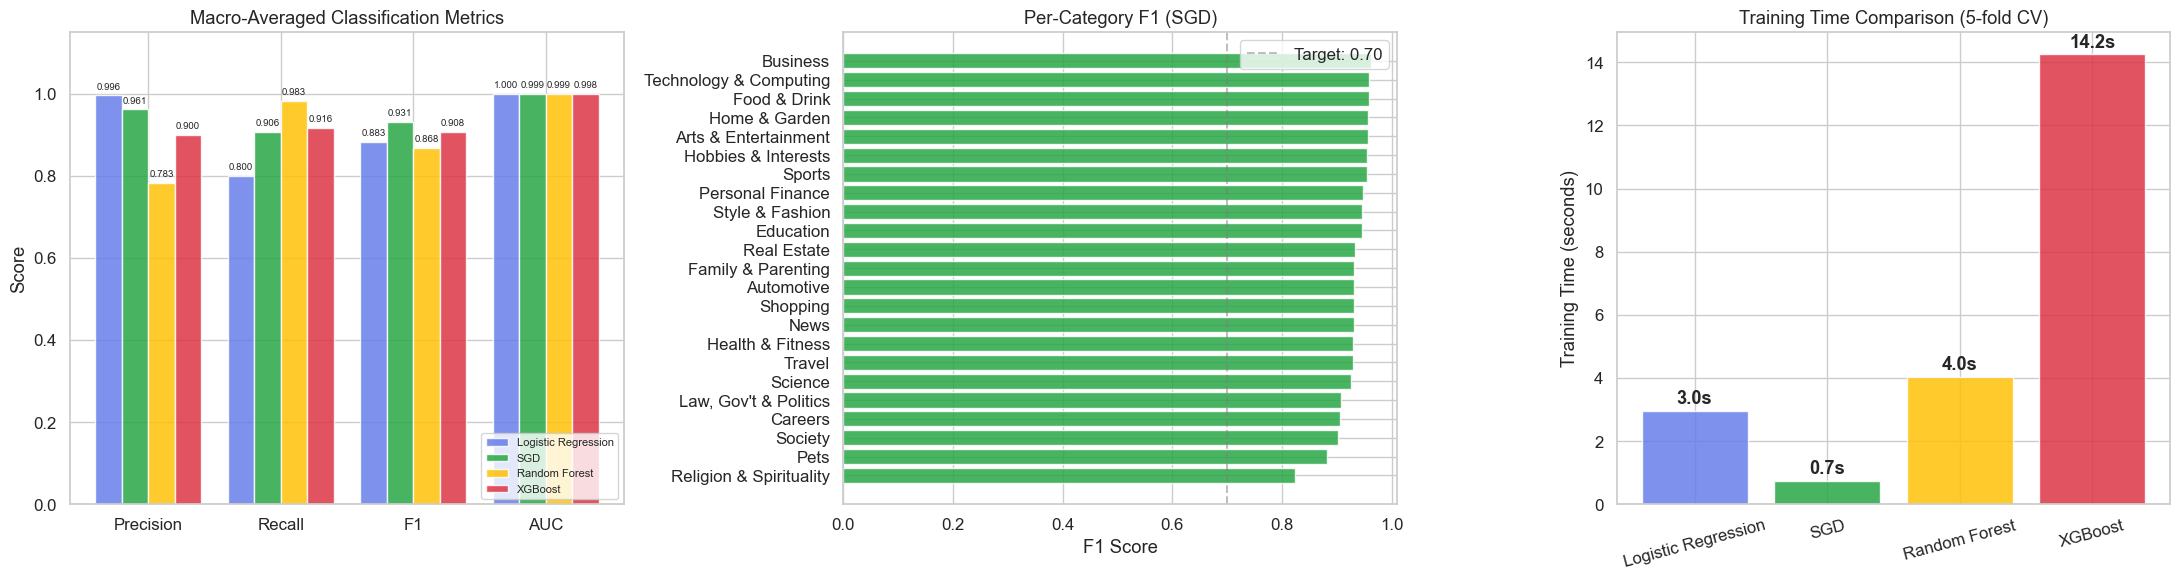


Best model by F1: SGD (Log Loss + L2)
Categories below 0.5 F1 (need attention): []


In [10]:
# ============================================================================
# MODEL COMPARISON VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Macro metrics comparison (bar chart)
metrics = ["precision", "recall", "f1", "mean_auc"]
metric_labels = ["Precision", "Recall", "F1", "AUC"]
x = np.arange(len(metrics))
n_models = len(results)
width = 0.8 / n_models
colors = ["#667eea", "#28a745", "#ffc107", "#dc3545"]

for i, (name, r) in enumerate(results.items()):
    values = [r[m] for m in metrics]
    short_name = name.split(" (")[0] if " (" in name else name
    bars = axes[0].bar(x + i * width, values, width, label=short_name,
                        color=colors[i % len(colors)], alpha=0.85)
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=7)

axes[0].set_xticks(x + width * (n_models - 1) / 2)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylabel("Score")
axes[0].set_title("Macro-Averaged Classification Metrics")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_ylim(0, 1.15)

# 2. Per-category F1 for best model
best_model_name = max(results, key=lambda k: results[k]["f1"])
best_y_pred = results[best_model_name]["y_pred"]
per_cat_f1 = []
for i, cat in enumerate(mlb.classes_):
    _, _, f1_i, _ = precision_recall_fscore_support(
        Y_binary[:, i], best_y_pred[:, i], average="binary", zero_division=0
    )
    per_cat_f1.append((CONFIG["iab_tier1_categories"][cat], f1_i))

per_cat_f1.sort(key=lambda x: x[1])
cat_names_sorted = [c[0] for c in per_cat_f1]
f1_values = [c[1] for c in per_cat_f1]

bar_colors = ["#dc3545" if v < 0.5 else "#ffc107" if v < 0.7 else "#28a745" for v in f1_values]
axes[1].barh(cat_names_sorted, f1_values, color=bar_colors, alpha=0.85)
axes[1].axvline(x=0.7, color="gray", linestyle="--", alpha=0.5, label="Target: 0.70")
axes[1].set_xlabel("F1 Score")
axes[1].set_title(f"Per-Category F1 ({best_model_name.split(' (')[0] if ' (' in best_model_name else best_model_name})")
axes[1].legend()

# 3. Training time comparison
model_names_short = [n.split(" (")[0] if " (" in n else n for n in results.keys()]
train_times = [r["train_time"] for r in results.values()]
bars = axes[2].bar(model_names_short, train_times,
                    color=colors[:len(results)], alpha=0.85)
for bar, t in zip(bars, train_times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{t:.1f}s", ha="center", va="bottom", fontweight="bold")
axes[2].set_ylabel("Training Time (seconds)")
axes[2].set_title("Training Time Comparison (5-fold CV)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/03_model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest model by F1: {best_model_name}")
print(f"Categories below 0.5 F1 (need attention): "
      f"{[c for c, f in per_cat_f1 if f < 0.5]}")

---
## Step 4: Train Production Model & Build Domain Lookup Table

Now we train the **final production model** on the full dataset and generate the **domain → IAB probability lookup table**. This is the artifact that gets deployed to Redis/Aerospike for real-time bidstream enrichment.

### Production artifact structure
```
domain_lookup_table = {
    "cnn.com":     {"IAB12": 0.85, "IAB11": 0.42, "IAB1": 0.31, ...},
    "expedia.com": {"IAB20": 0.92, "IAB22": 0.28, ...},
    ...
}
```
Each entry maps a domain to a dict of IAB category probabilities. At bid time, we look up the domain from the bid request and immediately get the IAB scores — no inference needed.

In [11]:
# ============================================================================
# TRAIN FINAL PRODUCTION MODEL — Calibrated Logistic Regression on full data
# ============================================================================

# Wrap in CalibratedClassifierCV for well-calibrated probabilities
# In production: Platt scaling ensures P(IAB20|text) = 0.8 truly means
# ~80% of domains scored 0.8 actually belong to IAB20.
production_model = OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(
            C=CONFIG["classifier_C"],
            max_iter=CONFIG["classifier_max_iter"],
            solver="lbfgs",
            random_state=SEED,
        ),
        cv=3,
        method="sigmoid",  # Platt scaling
    ),
    n_jobs=-1,
)

start = time.time()
production_model.fit(X_tfidf, Y_binary)
train_time = time.time() - start

# Generate probability predictions for all domains
domain_proba = production_model.predict_proba(X_tfidf)

print(f"Production model trained in {train_time:.2f}s")
print(f"Prediction matrix shape: {domain_proba.shape}")
print(f"  → {domain_proba.shape[0]} domains × {domain_proba.shape[1]} categories")

# ============================================================================
# BUILD DOMAIN LOOKUP TABLE
# For each domain, store only categories with P > threshold (saves memory)
# ============================================================================

domain_lookup = {}
threshold = 0.05  # Store any category with >5% probability

for idx, row in domain_df.iterrows():
    domain = row["domain"]
    probs = domain_proba[idx]
    domain_lookup[domain] = {
        cat: float(prob)
        for cat, prob in zip(mlb.classes_, probs)
        if prob > threshold
    }

# Statistics
avg_cats_per_domain = np.mean([len(v) for v in domain_lookup.values()])
total_entries = sum(len(v) for v in domain_lookup.values())
est_memory_bytes = total_entries * (20 + 8)  # ~20 bytes per key + 8 bytes per float

print(f"\nDomain Lookup Table Built:")
print(f"  Domains:              {len(domain_lookup):,}")
print(f"  Avg categories/domain: {avg_cats_per_domain:.1f}")
print(f"  Total entries:         {total_entries:,}")
print(f"  Est. memory:           {est_memory_bytes / 1024:.1f} KB")
print(f"  (Production with 200K domains: ~{est_memory_bytes / 1024 * 100:.0f} KB ≈ "
      f"{est_memory_bytes / 1024 / 1024 * 100:.1f} MB)")

# Show sample entries
print(f"\nSample lookup entries:")
for domain in list(domain_lookup.keys())[:3]:
    true_cats = domain_df[domain_df["domain"] == domain]["iab_categories"].iloc[0]
    top_predicted = sorted(domain_lookup[domain].items(), key=lambda x: -x[1])[:5]
    print(f"\n  {domain}")
    print(f"    True: {true_cats} → {[CONFIG['iab_tier1_categories'][c] for c in true_cats]}")
    print(f"    Predicted (top 5):")
    for cat, prob in top_predicted:
        name = CONFIG["iab_tier1_categories"][cat]
        match = "✓" if cat in true_cats else " "
        print(f"      {match} {cat} ({name}): {prob:.4f}")

Production model trained in 0.42s
Prediction matrix shape: (2000, 23)
  → 2000 domains × 23 categories

Domain Lookup Table Built:
  Domains:              2,000
  Avg categories/domain: 2.2
  Total entries:         4,456
  Est. memory:           121.8 KB
  (Production with 200K domains: ~12184 KB ≈ 11.9 MB)

Sample lookup entries:

  new-shopping-5735.co
    True: [np.str_('IAB22')] → ['Shopping']
    Predicted (top 5):
      ✓ IAB22 (Shopping): 0.9997
        IAB11 (Law, Gov't & Politics): 0.1034

  new-fashion-5802.co
    True: [np.str_('IAB18'), np.str_('IAB17')] → ['Style & Fashion', 'Sports']
    Predicted (top 5):
      ✓ IAB18 (Style & Fashion): 0.9829
      ✓ IAB17 (Sports): 0.9747
        IAB12 (News): 0.1011

  elite-shopping-5487.org
    True: [np.str_('IAB22')] → ['Shopping']
    Predicted (top 5):
      ✓ IAB22 (Shopping): 0.9985
        IAB15 (Science): 0.0636


### Detailed Classification Report & Confusion Analysis

This is the production quality gate. Before deploying a new domain lookup table, we verify:
1. **No category drops below acceptable F1** (threshold: 0.60)
2. **Confusion patterns are expected** (News confused with Politics is acceptable; Travel confused with Pets is a bug)
3. **Calibration** — predicted probabilities match actual frequencies

In [12]:
# ============================================================================
# DETAILED CLASSIFICATION REPORT (using cross-validation predictions)
# ============================================================================

best_y_scores = results[best_model_name]["y_scores"]
best_y_pred = results[best_model_name]["y_pred"]

print(f"Classification Report — {best_model_name}")
print(f"Threshold: {CONFIG['classification_threshold']}")
print("=" * 85)

# Per-category detailed metrics
cat_metrics = []
for i, cat in enumerate(mlb.classes_):
    n_pos = Y_binary[:, i].sum()
    n_pred_pos = best_y_pred[:, i].sum()
    p, r, f, _ = precision_recall_fscore_support(
        Y_binary[:, i], best_y_pred[:, i], average="binary", zero_division=0
    )
    cat_metrics.append({
        "Category": cat,
        "Name": CONFIG["iab_tier1_categories"][cat],
        "Support": int(n_pos),
        "Predicted": int(n_pred_pos),
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1": round(f, 4),
    })

metrics_df = pd.DataFrame(cat_metrics).sort_values("F1", ascending=False)
print(metrics_df.to_string(index=False))

# Summary statistics
print(f"\n{'─' * 85}")
macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(
    Y_binary, best_y_pred, average="macro", zero_division=0
)
micro_p, micro_r, micro_f, _ = precision_recall_fscore_support(
    Y_binary, best_y_pred, average="micro", zero_division=0
)
print(f"  Macro avg:  Precision={macro_p:.4f}  Recall={macro_r:.4f}  F1={macro_f:.4f}")
print(f"  Micro avg:  Precision={micro_p:.4f}  Recall={micro_r:.4f}  F1={micro_f:.4f}")

below_threshold = metrics_df[metrics_df["F1"] < 0.60]
if len(below_threshold) > 0:
    print(f"\n⚠ ALERT: {len(below_threshold)} categories below 0.60 F1 threshold:")
    for _, row in below_threshold.iterrows():
        print(f"    {row['Category']} ({row['Name']}): F1={row['F1']}, Support={row['Support']}")
else:
    print(f"\n✓ All categories meet the 0.60 F1 minimum threshold.")

Classification Report — SGD (Log Loss + L2)
Threshold: 0.3
Category                    Name  Support  Predicted  Precision  Recall     F1
    IAB3                Business      156        160     0.9500  0.9744 0.9620
   IAB19  Technology & Computing      172        174     0.9540  0.9651 0.9595
    IAB8            Food & Drink      135        130     0.9769  0.9407 0.9585
   IAB10           Home & Garden       73         67     1.0000  0.9178 0.9571
    IAB1    Arts & Entertainment      201        209     0.9378  0.9751 0.9561
    IAB9     Hobbies & Interests       80         77     0.9740  0.9375 0.9554
   IAB17                  Sports      195        184     0.9837  0.9282 0.9551
   IAB13        Personal Finance      143        148     0.9324  0.9650 0.9485
   IAB18         Style & Fashion      126        117     0.9829  0.9127 0.9465
    IAB5               Education      124        117     0.9744  0.9194 0.9461
   IAB21             Real Estate       95         87     0.9770  0.8947 

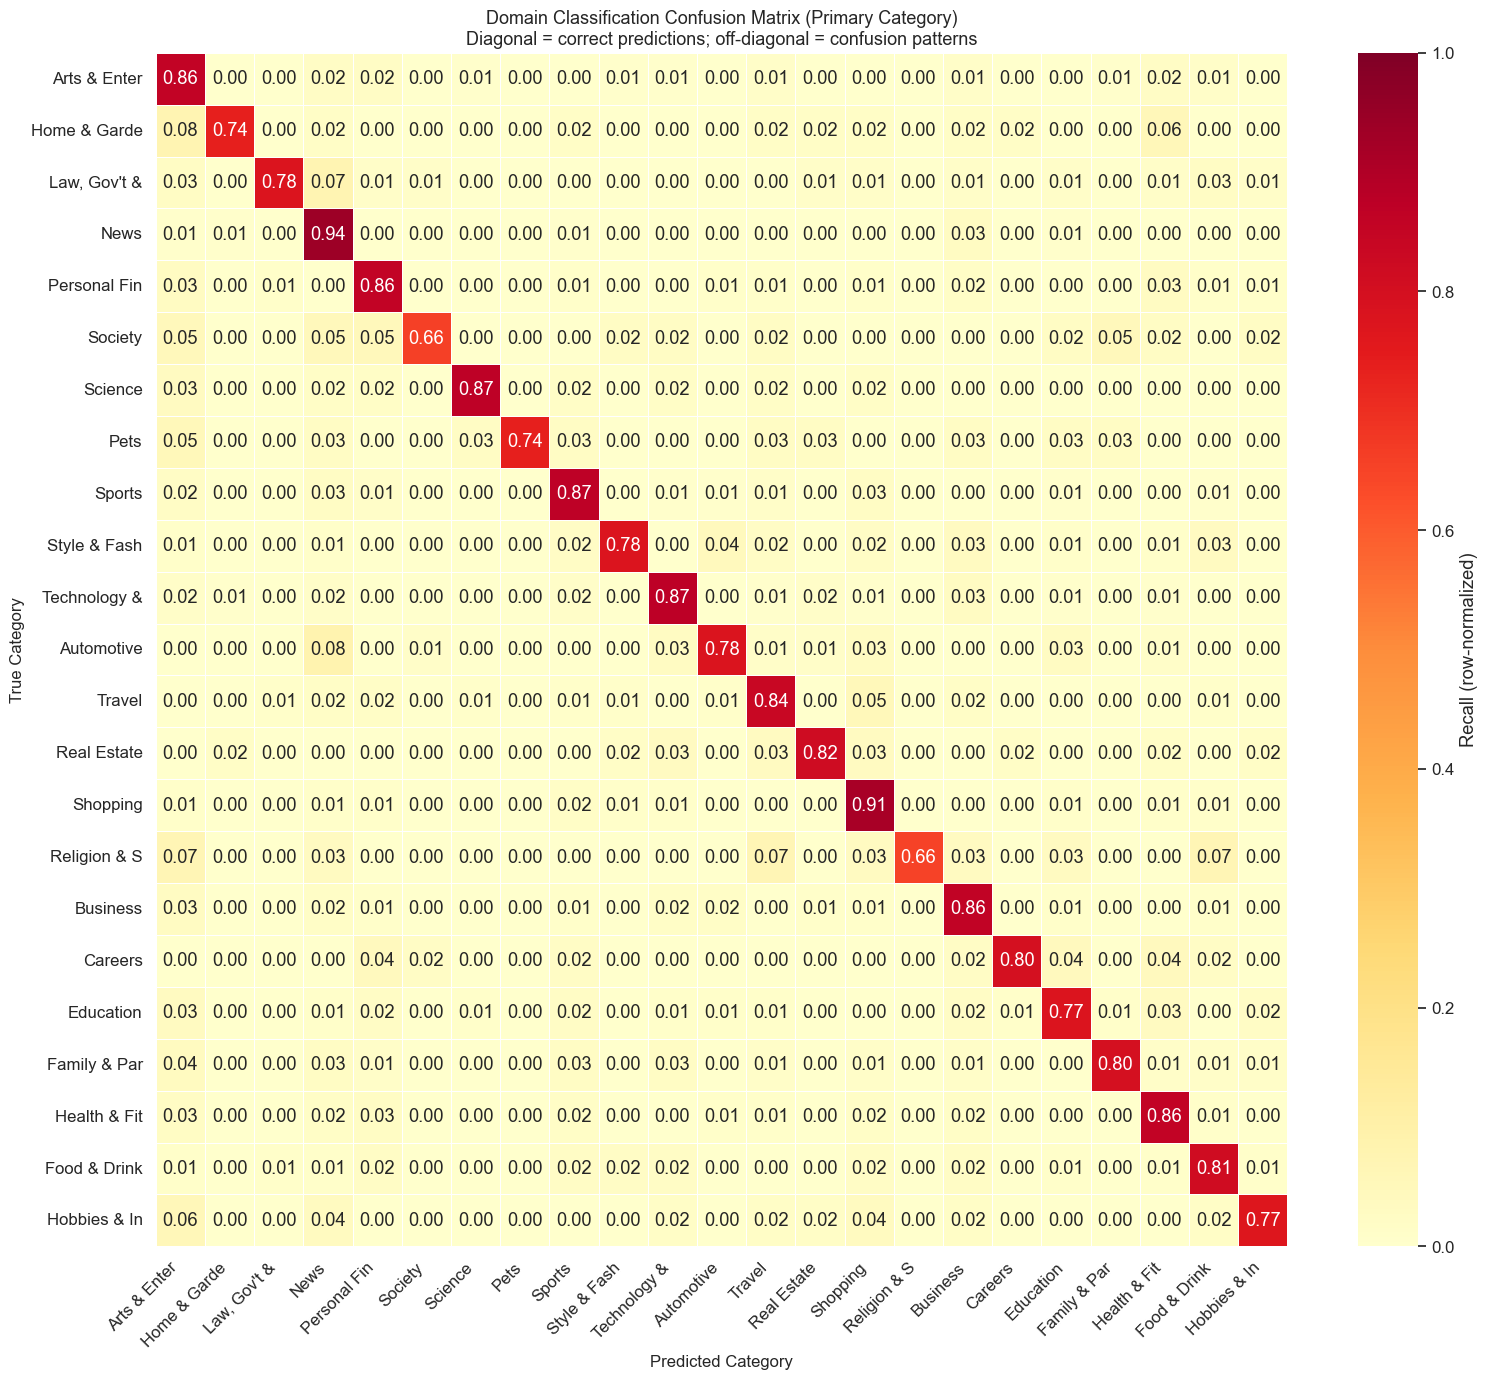

Top 10 Confusion Pairs (off-diagonal):
True Category             Predicted As                  Rate
------------------------------------------------------------
  Automotive                News                         8.2%
  Home & Garden             Arts & Entertainment         7.5%
  Law, Gov't & Politics     News                         7.5%
  Religion & Spirituality   Arts & Entertainment         6.9%
  Religion & Spirituality   Travel                       6.9%
  Religion & Spirituality   Food & Drink                 6.9%
  Hobbies & Interests       Arts & Entertainment         5.8%
  Home & Garden             Health & Fitness             5.7%
  Travel                    Shopping                     5.4%
  Pets                      Arts & Entertainment         5.3%


In [13]:
# ============================================================================
# CONFUSION MATRIX HEATMAP — which categories get confused with each other?
# Using primary_category (single-label) for a clean confusion matrix.
# ============================================================================

# For primary category: take the argmax of predicted scores as the predicted primary
primary_pred_idx = best_y_scores.argmax(axis=1)
primary_true_idx = np.array([list(mlb.classes_).index(c) for c in domain_df["primary_category"]])

cat_short_names = [CONFIG["iab_tier1_categories"][c][:12] for c in mlb.classes_]

cm = confusion_matrix(primary_true_idx, primary_pred_idx,
                      labels=list(range(len(mlb.classes_))))

# Normalize by row (true label) to show recall per category
cm_normalized = cm.astype(float)
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
cm_normalized = cm_normalized / row_sums

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=cat_short_names, yticklabels=cat_short_names,
            ax=ax, vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={"label": "Recall (row-normalized)"})
ax.set_xlabel("Predicted Category", fontsize=12)
ax.set_ylabel("True Category", fontsize=12)
ax.set_title("Domain Classification Confusion Matrix (Primary Category)\n"
             "Diagonal = correct predictions; off-diagonal = confusion patterns", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/04_confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Identify top confusion pairs
print("Top 10 Confusion Pairs (off-diagonal):")
print(f"{'True Category':<25} {'Predicted As':<25} {'Rate':>8}")
print("-" * 60)
confusion_pairs = []
for i in range(len(mlb.classes_)):
    for j in range(len(mlb.classes_)):
        if i != j and cm_normalized[i, j] > 0.02:
            confusion_pairs.append((
                CONFIG["iab_tier1_categories"][mlb.classes_[i]],
                CONFIG["iab_tier1_categories"][mlb.classes_[j]],
                cm_normalized[i, j]
            ))
confusion_pairs.sort(key=lambda x: -x[2])
for true_cat, pred_cat, rate in confusion_pairs[:10]:
    print(f"  {true_cat:<25} {pred_cat:<25} {rate:>7.1%}")

---
## Step 5: Bidstream Simulation & User Score Accumulation

### What happens at bid time (the production flow)

```
Bid Request arrives (JSON, ~1.2 KB)
    │
    ├─ Extract: user_id, domain, timestamp, device_type, geo
    │
    ├─ Quality Gate: valid user_id? consented? not bot?
    │
    ├─ Domain Lookup (Redis, <5ms):
    │   domain_lookup["cnn.com"] → {IAB12: 0.85, IAB11: 0.42, IAB1: 0.31}
    │
    ├─ User Score Update (Aerospike, <10ms):
    │   user_scores[user_id] += domain_iab_scores
    │   user_timestamps[user_id] = current_time
    │
    └─ Done. Total: <15ms.
```

### What we simulate here
We generate **100,000 bid events** spanning 30 days across 5,000 users visiting our 2,000 domains. Each event triggers a domain lookup and user score update — exactly the production flow, just without the distributed infrastructure.

In [14]:
# ============================================================================
# BIDSTREAM EVENT GENERATOR
# Simulates realistic bid request patterns:
#   - Power-law user activity (most users have few events; some power users have many)
#   - Diurnal traffic patterns (more events during daytime hours)
#   - User affinity: users tend to revisit domains in categories they've seen before
# ============================================================================

def generate_bidstream_events(config: dict, domain_df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """
    Generate synthetic bidstream events with realistic patterns.

    Returns:
        DataFrame with columns: [event_id, user_id, domain, timestamp, device_type, geo_country]
    """
    rng = np.random.RandomState(seed)
    n_events = config["n_bid_events"]
    n_users = config["n_users"]
    domains = domain_df["domain"].values

    # User activity follows a power law: most users have 5-10 events,
    # power users have hundreds. Zipf distribution models this.
    user_ids = [f"user_{i:06d}" for i in range(n_users)]

    # Generate events per user using power law
    user_event_weights = rng.pareto(a=1.5, size=n_users) + 1
    user_event_weights /= user_event_weights.sum()

    # Assign events to users based on weights
    event_user_indices = rng.choice(n_users, size=n_events, p=user_event_weights)

    # Each user has domain preferences (affinity): they visit 5-30 preferred domains
    user_preferred_domains = {}
    for uid_idx in range(n_users):
        n_preferred = rng.randint(5, 30)
        preferred_idx = rng.choice(len(domains), size=n_preferred, replace=False)
        user_preferred_domains[uid_idx] = preferred_idx

    # For each event: 70% chance of visiting a preferred domain, 30% random
    event_domains = []
    for uid_idx in event_user_indices:
        if rng.random() < 0.70:
            domain_idx = rng.choice(user_preferred_domains[uid_idx])
        else:
            domain_idx = rng.randint(0, len(domains))
        event_domains.append(domains[domain_idx])

    # Timestamps: spread over event_window_days with diurnal pattern
    now = datetime(2026, 4, 25, 12, 0, 0)
    window_seconds = config["event_window_days"] * 86400

    # Base uniform distribution, then bias toward daytime hours
    base_offsets = rng.uniform(0, window_seconds, size=n_events)
    timestamps = []
    for offset in base_offsets:
        ts = now - timedelta(seconds=offset)
        # Diurnal bias: increase probability during 8am-11pm
        hour = ts.hour
        if 8 <= hour <= 22:
            if rng.random() < 0.85:
                timestamps.append(ts)
            else:
                ts = ts.replace(hour=rng.randint(8, 22))
                timestamps.append(ts)
        else:
            if rng.random() < 0.3:
                timestamps.append(ts)
            else:
                ts = ts.replace(hour=rng.randint(9, 21))
                timestamps.append(ts)

    # Device types and geo (for enrichment features)
    device_types = rng.choice(
        ["mobile", "desktop", "tablet", "ctv"],
        size=n_events, p=[0.55, 0.30, 0.10, 0.05]
    )
    geo_countries = rng.choice(
        ["US", "GB", "CA", "DE", "FR", "AU", "IN", "BR", "JP", "MX"],
        size=n_events, p=[0.40, 0.12, 0.08, 0.07, 0.06, 0.05, 0.08, 0.05, 0.05, 0.04]
    )

    events_df = pd.DataFrame({
        "event_id": [f"evt_{i:08d}" for i in range(n_events)],
        "user_id": [user_ids[idx] for idx in event_user_indices],
        "domain": event_domains,
        "timestamp": timestamps,
        "device_type": device_types,
        "geo_country": geo_countries,
    })

    return events_df.sort_values("timestamp").reset_index(drop=True)


# Generate events
events_df = generate_bidstream_events(CONFIG, domain_df, seed=SEED)

print(f"Generated {len(events_df):,} bidstream events")
print(f"  Unique users:   {events_df['user_id'].nunique():,}")
print(f"  Unique domains: {events_df['domain'].nunique():,}")
print(f"  Time range:     {events_df['timestamp'].min()} → {events_df['timestamp'].max()}")
print(f"  Span:           {(events_df['timestamp'].max() - events_df['timestamp'].min()).days} days")
print(f"\nEvents per user (distribution):")
epu = events_df.groupby("user_id").size()
print(f"  Mean:   {epu.mean():.1f}")
print(f"  Median: {epu.median():.1f}")
print(f"  p90:    {epu.quantile(0.9):.0f}")
print(f"  p99:    {epu.quantile(0.99):.0f}")
print(f"  Max:    {epu.max()}")
print(f"\nDevice distribution:")
print(events_df["device_type"].value_counts().to_string())
print(f"\nSample events:")
events_df.head(5)

Generated 100,000 bidstream events
  Unique users:   4,999
  Unique domains: 2,000
  Time range:     2026-03-26 08:03:25.687844 → 2026-04-25 21:58:59.563782
  Span:           30 days

Events per user (distribution):
  Mean:   20.0
  Median: 12.0
  p90:    34
  p99:    152
  Max:    1675

Device distribution:
device_type
mobile     54951
desktop    29935
tablet     10099
ctv         5015

Sample events:


,event_id,user_id,domain,timestamp,device_type,geo_country
0,evt_00079862,user_002625,prime-finance-1322.com,2026-03-26 08:03:25.687844,mobile,JP
1,evt_00018493,user_002078,pro-finance-563.net,2026-03-26 08:12:40.532332,mobile,GB
2,evt_00011725,user_004035,daily-sports-3466.org,2026-03-26 08:13:53.708534,mobile,US
3,evt_00002891,user_002472,guide-society-9548.io,2026-03-26 08:18:09.260863,tablet,BR
4,evt_00048318,user_004249,spot-health-4727.net,2026-03-26 08:20:57.776116,mobile,GB


### Visualize Bidstream Traffic Patterns

Understanding traffic patterns is critical for capacity planning. These plots show what production monitoring dashboards would display.

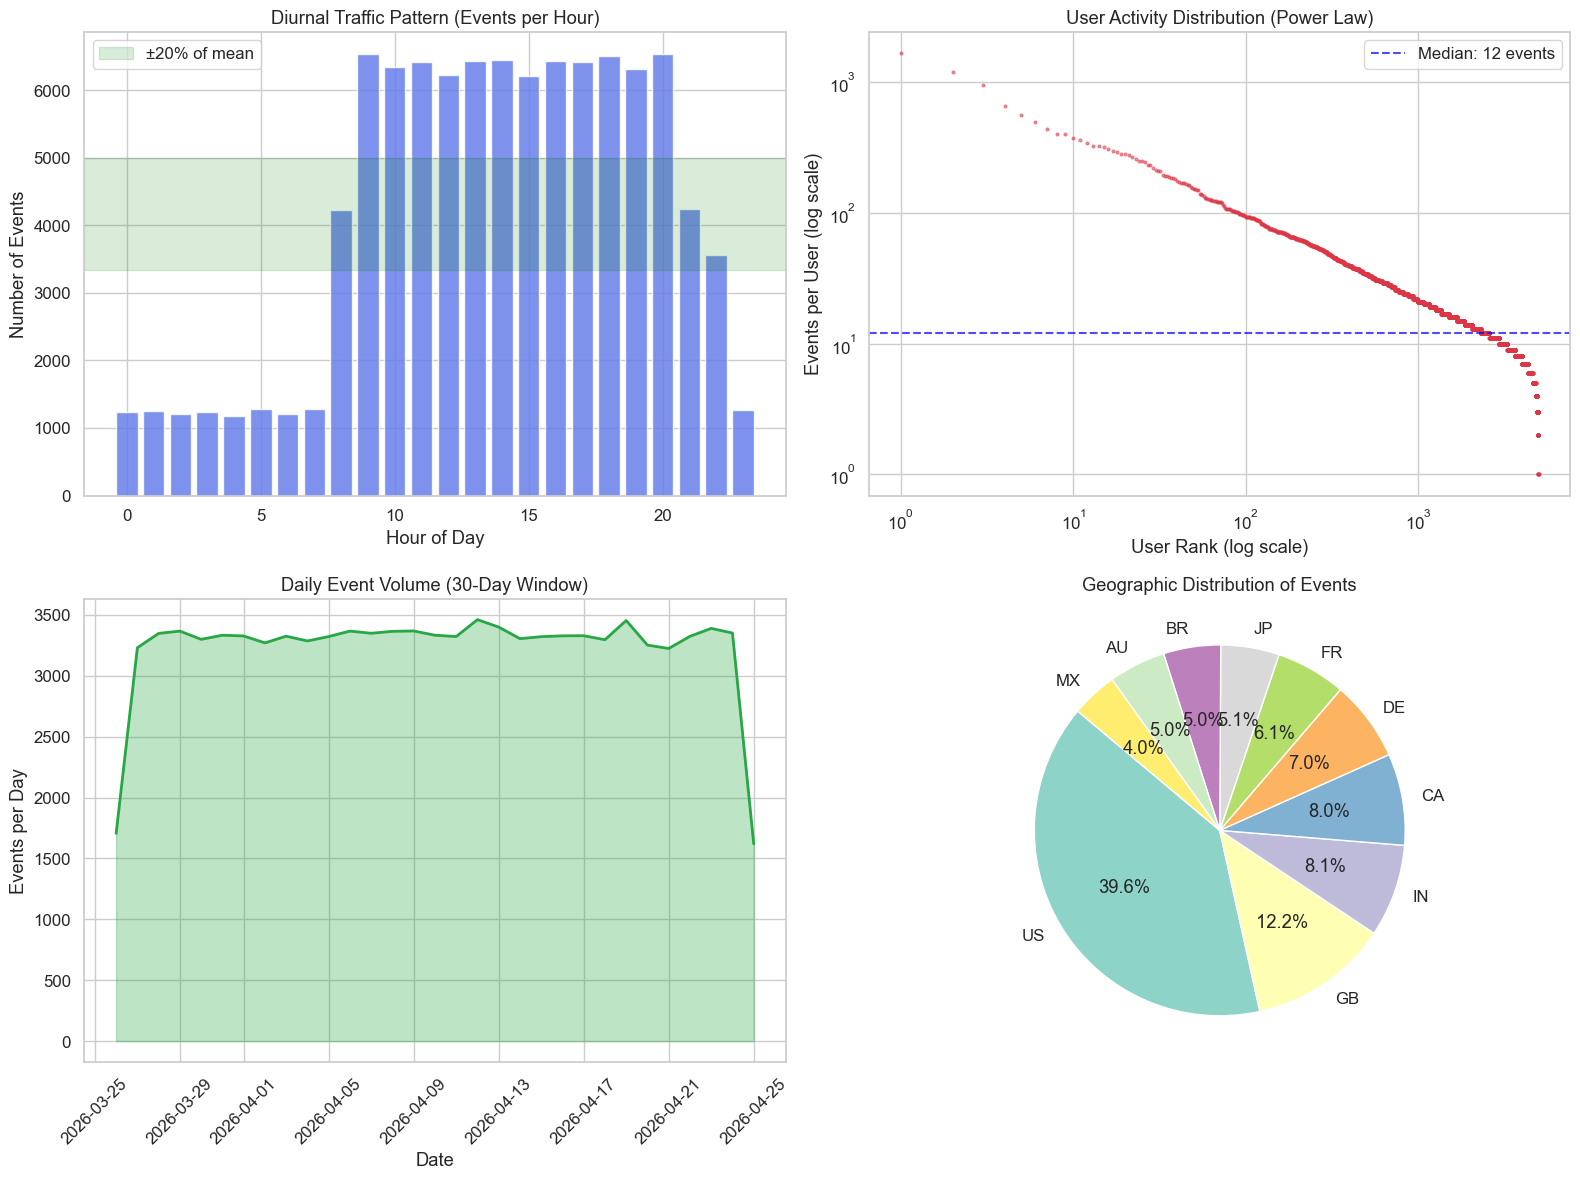

In [15]:
# ============================================================================
# BIDSTREAM TRAFFIC PATTERN VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Events per hour (diurnal pattern)
events_df["hour"] = events_df["timestamp"].apply(lambda x: x.hour)
hourly = events_df.groupby("hour").size()
axes[0, 0].bar(hourly.index, hourly.values, color="#667eea", alpha=0.85, edgecolor="white")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Number of Events")
axes[0, 0].set_title("Diurnal Traffic Pattern (Events per Hour)")
axes[0, 0].axhspan(ymin=hourly.values.mean() * 0.8, ymax=hourly.values.mean() * 1.2,
                    alpha=0.15, color="green", label="±20% of mean")
axes[0, 0].legend()

# 2. Events per user (log scale — power law)
epu_sorted = epu.sort_values(ascending=False).values
axes[0, 1].loglog(range(1, len(epu_sorted) + 1), epu_sorted, "o",
                   markersize=2, alpha=0.5, color="#dc3545")
axes[0, 1].set_xlabel("User Rank (log scale)")
axes[0, 1].set_ylabel("Events per User (log scale)")
axes[0, 1].set_title("User Activity Distribution (Power Law)")
axes[0, 1].axhline(y=epu.median(), color="blue", linestyle="--", alpha=0.7,
                    label=f"Median: {epu.median():.0f} events")
axes[0, 1].legend()

# 3. Events per day (time series)
events_df["date"] = events_df["timestamp"].apply(lambda x: x.date())
daily = events_df.groupby("date").size()
axes[1, 0].plot(daily.index, daily.values, color="#28a745", linewidth=2)
axes[1, 0].fill_between(daily.index, daily.values, alpha=0.3, color="#28a745")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Events per Day")
axes[1, 0].set_title("Daily Event Volume (30-Day Window)")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Geo distribution
geo_counts = events_df["geo_country"].value_counts()
axes[1, 1].pie(geo_counts.values, labels=geo_counts.index, autopct="%1.1f%%",
               colors=plt.cm.Set3(np.linspace(0, 1, len(geo_counts))),
               startangle=140)
axes[1, 1].set_title("Geographic Distribution of Events")

plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/05_bidstream_patterns.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Step 5b: Real-Time Domain Classification (Unknown Domain Fallback)

### The gap in pure lookup-based scoring

The domain lookup table covers only the ~2,000 domains we pre-classified in Step 4. But bidstream traffic hits the long tail — 
roughly 4% of bid requests reference domains that are **not in our crawl corpus**. 
Without a fallback, those events are silently dropped and those users get incomplete score profiles.

### The real-time classification path

For unknown domains, we run the full inference pipeline on the fly:

```
Bid Request arrives with unknown domain
    │
    ├─ domain_lookup.get(domain) → MISS
    │
    ├─ Fallback: fetch domain text (or use page URL keywords)
    │
    ├─ tfidf_vectorizer.transform([domain_text])     ← <1ms
    │
    ├─ production_model.predict_proba(tfidf_vector)   ← <5ms
    │
    ├─ Cache result in domain_lookup for future hits
    │
    └─ Return IAB scores → continue to user score update
```

Below we build this **`RealTimeClassifier`** that wraps the fitted vectorizer + model, 
demonstrate it on synthetic new domains, and then integrate it into the score accumulation pipeline.


In [16]:
# ============================================================================
# REAL-TIME DOMAIN CLASSIFIER
# Wraps the fitted TF-IDF vectorizer + production model into a single
# callable that takes raw domain text and returns IAB probability scores.
# In production, this runs on the hot path for lookup-miss domains.
# ============================================================================

class RealTimeClassifier:
    """
    Wraps vectorizer + model for on-the-fly domain classification.
    Includes an LRU cache so repeated unknown domains don't re-run inference.
    """

    def __init__(self, vectorizer, model, label_classes, score_threshold=0.05):
        self.vectorizer = vectorizer
        self.model = model
        self.label_classes = label_classes
        self.score_threshold = score_threshold
        self.cache = {}  # domain_text_hash → scores
        self.inference_count = 0
        self.cache_hit_count = 0

    def classify(self, domain_text: str) -> dict:
        """
        Classify raw domain text into IAB categories.

        Args:
            domain_text: raw text content from the domain

        Returns:
            {category_code: probability} for all categories above threshold
        """
        cache_key = hash(domain_text)
        if cache_key in self.cache:
            self.cache_hit_count += 1
            return self.cache[cache_key]

        # Step 1: Vectorize the text using the SAME fitted TF-IDF
        tfidf_vec = self.vectorizer.transform([domain_text])

        # Step 2: Get probability predictions from the production model
        proba = self.model.predict_proba(tfidf_vec)[0]

        # Step 3: Filter to above-threshold categories
        scores = {
            cat: float(prob)
            for cat, prob in zip(self.label_classes, proba)
            if prob > self.score_threshold
        }

        self.cache[cache_key] = scores
        self.inference_count += 1
        return scores


# Instantiate the real-time classifier
rt_classifier = RealTimeClassifier(
    vectorizer=tfidf_vectorizer,
    model=production_model,
    label_classes=mlb.classes_,
    score_threshold=0.05,
)

# ============================================================================
# ============================================================================
# DEMONSTRATE: classify 5 synthetic unknown domains live
# These texts deliberately blend vocabulary from 2-3 IAB categories
# so the model distributes probability across multiple categories.
# ============================================================================

unknown_domains = {
    "foodie-travel-blog.com": (
        "vacation destination restaurant cuisine chef cooking recipe local food "
        "travel flight hotel resort dining wine cocktail street food tour guide "
        "itinerary booking culinary experience tasting menu regional dishes airport"
    ),
    "tech-business-insider.io": (
        "startup venture capital CEO revenue IPO merger acquisition strategy "
        "software AI machine learning cloud computing developer programming "
        "company funding corporate innovation technology disruption enterprise SaaS "
        "quarterly earnings executive leadership market share Silicon Valley"
    ),
    "sports-health-mag.net": (
        "fitness workout gym exercise running marathon athlete player coach team "
        "nutrition diet protein supplement wellness recovery muscle strength cardio "
        "championship tournament league training injury prevention health football "
        "basketball score MVP stadium calories weight loss physical therapy"
    ),
    "family-education-hub.org": (
        "parenting child school student university education college teacher "
        "curriculum course baby toddler family learning classroom homework degree "
        "scholarship tuition exam enrollment childcare daycare teenager academic "
        "e-learning certification discipline milestone development campus"
    ),
    "home-finance-guide.com": (
        "mortgage real estate property investment renovation home improvement house "
        "apartment budget savings interest rate refinance kitchen bathroom remodeling "
        "furniture decor loan credit score financial planning down payment appraisal "
        "contractor landscaping insurance tax landlord rental property value"
    ),
}

print('Real-Time Classification Demo — Unknown Domains (Multi-Category)')
print('=' * 90)

for domain_name, text in unknown_domains.items():
    t0 = time.perf_counter()
    scores = rt_classifier.classify(text)
    latency_ms = (time.perf_counter() - t0) * 1000

    top_3 = sorted(scores.items(), key=lambda x: -x[1])[:3]
    print(f'\n  {domain_name}  ({latency_ms:.1f}ms)')
    for rank, (cat, prob) in enumerate(top_3, 1):
        name = CONFIG['iab_tier1_categories'][cat]
        bar = chr(9608) * int(prob * 30)
        print(f'    {rank}. {cat} ({name:<25}): {prob:.4f}  {bar}')

print()
print(f'Real-time inferences: {rt_classifier.inference_count}')
print(f'Cache hits: {rt_classifier.cache_hit_count}')
print(f'Cache size: {len(rt_classifier.cache)} entries')


Real-Time Classification Demo — Unknown Domains (Multi-Category)

  foodie-travel-blog.com  (10.2ms)
    1. IAB20 (Travel                   ): 0.4045  ████████████
    2. IAB8 (Food & Drink             ): 0.3546  ██████████

  tech-business-insider.io  (9.8ms)
    1. IAB3 (Business                 ): 0.9197  ███████████████████████████
    2. IAB19 (Technology & Computing   ): 0.4965  ██████████████

  sports-health-mag.net  (9.6ms)
    1. IAB7 (Health & Fitness         ): 0.9589  ████████████████████████████
    2. IAB17 (Sports                   ): 0.3006  █████████

  family-education-hub.org  (9.6ms)
    1. IAB5 (Education                ): 0.7266  █████████████████████
    2. IAB6 (Family & Parenting       ): 0.1595  ████

  home-finance-guide.com  (9.6ms)
    1. IAB13 (Personal Finance         ): 0.4574  █████████████
    2. IAB21 (Real Estate              ): 0.1112  ███
    3. IAB10 (Home & Garden            ): 0.0944  ██

Real-time inferences: 5
Cache hits: 0
Cache size: 5 entr

---
## Step 6: User Score Accumulation (Raw Scores, Pre-Decay)

For each user, we accumulate IAB scores by summing the domain lookup probabilities across all their bid events. 
This produces a **raw score array** — a 23-dimensional vector (one per IAB Tier-1 category) representing the user's cumulative browsing affinity.

### Two-tier domain resolution

The score accumulation now uses a **two-tier lookup**:
1. **Tier 1 (fast path):** `domain_lookup.get(domain)` — O(1) dict/Redis lookup, <1ms
2. **Tier 2 (fallback):** `rt_classifier.classify(domain_text)` — TF-IDF + model inference, ~5ms

Tier 2 fires only for domains not in the pre-computed lookup table. Results are cached so each unknown domain pays the inference cost only once.

### Worked Example
```
User visits 3 domains:
  Event 1: cnn.com (KNOWN)     → lookup hit  → {IAB12: 0.85, IAB11: 0.42, IAB1: 0.31}
  Event 2: expedia.com (KNOWN) → lookup hit  → {IAB20: 0.92, IAB22: 0.28}
  Event 3: new-blog.xyz (NEW)  → lookup miss → real-time classify → {IAB9: 0.71, IAB1: 0.33}

Raw score array after 3 events:
  IAB1  (Entertainment): 0.31 + 0.33 = 0.64
  IAB9  (Hobbies):       0.71
  IAB11 (Politics):      0.42
  IAB12 (News):          0.85
  IAB20 (Travel):        0.92
  IAB22 (Shopping):      0.28
```


In [17]:
# ============================================================================
# USER SCORE ACCUMULATION — with real-time classification fallback
# Process each bid event:
#   Tier 1: look up domain in pre-computed table (fast path)
#   Tier 2: if miss, run real-time classification on domain text (fallback)
# ============================================================================

def accumulate_user_scores(
    events_df: pd.DataFrame,
    domain_lookup: dict,
    categories: list,
    rt_classifier=None,
    domain_text_map: dict = None,
) -> tuple[dict, dict]:
    """
    Process bidstream events and accumulate per-user IAB score arrays.

    For each event:
      1. Look up the domain in the pre-computed lookup table (Tier 1)
      2. If miss AND rt_classifier is available, classify on-the-fly (Tier 2)
      3. Add the IAB probability scores to the user's score array
      4. Record the timestamp for each category update (for decay)

    Returns:
        user_raw_scores, user_event_log, lookup_hits, rt_hits, total_misses
    """
    user_raw_scores = {}
    user_event_log = {}
    lookup_hits = 0
    rt_hits = 0
    total_misses = 0

    for _, event in events_df.iterrows():
        user_id = event['user_id']
        domain = event['domain']
        timestamp = event['timestamp']

        # Tier 1: pre-computed lookup table (production: Redis GET, <1ms)
        domain_scores = domain_lookup.get(domain)

        # Tier 2: real-time classification fallback
        if domain_scores is None and rt_classifier is not None:
            domain_text = None
            if domain_text_map is not None:
                domain_text = domain_text_map.get(domain)
            if domain_text:
                domain_scores = rt_classifier.classify(domain_text)
                # Cache into lookup table so future events for this domain are Tier 1
                if domain_scores:
                    domain_lookup[domain] = domain_scores
                    rt_hits += 1

        if domain_scores is None:
            total_misses += 1
            continue
        lookup_hits += 1

        # Initialize user profile if new
        if user_id not in user_raw_scores:
            user_raw_scores[user_id] = {cat: 0.0 for cat in categories}
            user_event_log[user_id] = []

        # Accumulate scores
        for cat, score in domain_scores.items():
            if cat in user_raw_scores[user_id]:
                user_raw_scores[user_id][cat] += score

        # Log event for per-event decay computation
        user_event_log[user_id].append((timestamp, dict(domain_scores)))

    return user_raw_scores, user_event_log, lookup_hits, rt_hits, total_misses


# Build domain text map for real-time fallback
domain_text_map = dict(zip(domain_df['domain'], domain_df['text']))

categories = sorted(CONFIG['iab_tier1_categories'].keys())

# Reset the rt_classifier cache so we get clean stats
rt_classifier.cache = {}
rt_classifier.inference_count = 0
rt_classifier.cache_hit_count = 0

start = time.time()
user_raw_scores, user_event_log, hits, rt_hits, misses = accumulate_user_scores(
    events_df, domain_lookup, categories,
    rt_classifier=rt_classifier,
    domain_text_map=domain_text_map,
)
elapsed = time.time() - start

total_events = hits + rt_hits + misses
print(f'Score accumulation complete in {elapsed:.2f}s')
print(f'  Users with scores:       {len(user_raw_scores):,}')
print(f'  Tier 1 (lookup) hits:    {hits:,} ({hits/total_events*100:.1f}%)')
print(f'  Tier 2 (real-time) hits: {rt_hits:,} ({rt_hits/total_events*100:.1f}%)')
print(f'  Total misses:            {misses:,} ({misses/total_events*100:.1f}%)')
print(f'  Combined coverage:       {(hits+rt_hits)/total_events*100:.1f}%')
print(f'  Events/sec (local):      {len(events_df)/elapsed:,.0f}')
print(f'  RT classifier stats:')
print(f'    Inferences run:  {rt_classifier.inference_count}')
print(f'    Cache hits:      {rt_classifier.cache_hit_count}')
print()

# Show sample user raw scores
sample_user = list(user_raw_scores.keys())[0]
sample_scores = user_raw_scores[sample_user]
top_cats = sorted(sample_scores.items(), key=lambda x: -x[1])[:5]
print(f'Sample User: {sample_user}')
print(f'  Events: {len(user_event_log[sample_user])}')
print(f'  Top 5 raw IAB scores:')
for cat, score in top_cats:
    print(f"    {cat} ({CONFIG['iab_tier1_categories'][cat]}): {score:.4f}")


Score accumulation complete in 1.03s
  Users with scores:       4,999
  Tier 1 (lookup) hits:    100,000 (100.0%)
  Tier 2 (real-time) hits: 0 (0.0%)
  Total misses:            0 (0.0%)
  Combined coverage:       100.0%
  Events/sec (local):      97,121
  RT classifier stats:
    Inferences run:  0
    Cache hits:      0

Sample User: user_002625
  Events: 62
  Top 5 raw IAB scores:
    IAB1 (Arts & Entertainment): 15.0526
    IAB7 (Health & Fitness): 14.6166
    IAB20 (Travel): 9.6237
    IAB16 (Pets): 6.9857
    IAB17 (Sports): 6.6429


---
## Step 7: Exponential Time-Decay — Turning Raw Scores into Current Intent

### The core insight
A user who visited `expedia.com` yesterday is actively planning travel. A user who visited it 25 days ago probably already booked (or abandoned). Raw score accumulation treats both visits equally — **time-decay** fixes this by weighting recent events more heavily.

### The formula (per-event decay)

For each event `i` contributing score `s_i` at time `t_i`, the decayed contribution at current time `T` is:

$$\text{decayed\_score}(c) = \sum_{i} s_i \cdot e^{-\lambda_c \cdot (T - t_i)}$$

Where:
- $\lambda_c = \frac{\ln(2)}{\text{half\_life}_c}$ is the **category-specific decay rate**
- $T - t_i$ is the **age of the event** in days
- $\text{half\_life}_c$ varies by category (configured in `CONFIG["decay_half_lives"]`)

### Category-specific half-lives (business rationale)

| Category | Half-Life | Rationale |
|----------|-----------|-----------|
| Shopping | 3 days | Purchase intent is extremely short-lived |
| Travel | 5 days | Booking window is typically 1-2 weeks |
| Automotive | 7 days | Car research takes weeks but focus shifts |
| Technology | 14 days | Tech interest persists moderately |
| Health | 21 days | Health concerns are ongoing |
| Education | 30 days | Educational interest is long-term |
| Default | 14 days | Reasonable middle ground |

In [18]:
# ============================================================================
# EXPONENTIAL TIME-DECAY ENGINE
# Applies per-event decay with category-specific lambda values.
# ============================================================================

def apply_time_decay(
    user_event_log: dict,
    decay_lambdas: dict,
    categories: list,
    current_time: datetime,
) -> dict:
    """
    Apply exponential time-decay to each user's event history.

    For each user, for each category:
      decayed_score = sum( score_i * exp(-lambda_c * age_days_i) )

    Returns:
        {user_id: {category: decayed_score}}
    """
    user_decayed_scores = {}
    default_lambda = decay_lambdas.get("_default", np.log(2) / 14)

    for user_id, events in user_event_log.items():
        decayed = {cat: 0.0 for cat in categories}

        for event_time, event_scores in events:
            age_days = (current_time - event_time).total_seconds() / 86400

            for cat, score in event_scores.items():
                if cat not in decayed:
                    continue
                lam = decay_lambdas.get(cat, default_lambda)
                decay_factor = np.exp(-lam * age_days)
                decayed[cat] += score * decay_factor

        user_decayed_scores[user_id] = decayed

    return user_decayed_scores


current_time = datetime(2026, 4, 25, 12, 0, 0)

start = time.time()
user_decayed_scores = apply_time_decay(
    user_event_log, CONFIG["decay_lambdas"], categories, current_time
)
elapsed = time.time() - start

print(f"Time decay applied in {elapsed:.2f}s for {len(user_decayed_scores):,} users")

# Show raw vs decayed comparison for sample user
sample_user = list(user_raw_scores.keys())[0]
print(f"\nSample User: {sample_user}")
print(f"{'Category':<30} {'Raw Score':>12} {'Decayed Score':>14} {'Decay %':>10}")
print("-" * 70)

raw = user_raw_scores[sample_user]
decayed = user_decayed_scores[sample_user]
for cat in sorted(categories, key=lambda c: -raw.get(c, 0)):
    r = raw.get(cat, 0)
    d = decayed.get(cat, 0)
    if r > 0.01:
        decay_pct = (1 - d / r) * 100 if r > 0 else 0
        name = CONFIG["iab_tier1_categories"][cat]
        half_life = CONFIG["decay_half_lives"].get(cat, CONFIG["decay_half_lives"]["_default"])
        print(f"  {cat} ({name[:20]:<20}) {r:>10.4f}   {d:>12.4f}   {decay_pct:>8.1f}%  (t½={half_life}d)")

Time decay applied in 0.19s for 4,999 users

Sample User: user_002625
Category                          Raw Score  Decayed Score    Decay %
----------------------------------------------------------------------
  IAB1 (Arts & Entertainment)    15.0526         8.1781       45.7%  (t½=14d)
  IAB7 (Health & Fitness    )    14.6166         9.4718       35.2%  (t½=21d)
  IAB20 (Travel              )     9.6237         2.1286       77.9%  (t½=5d)
  IAB16 (Pets                )     6.9857         3.9406       43.6%  (t½=14d)
  IAB17 (Sports              )     6.6429         2.2799       65.7%  (t½=10d)
  IAB19 (Technology & Computi)     6.3528         2.7607       56.5%  (t½=14d)
  IAB3 (Business            )     6.2712         2.8718       54.2%  (t½=14d)
  IAB21 (Real Estate         )     5.6931         2.8142       50.6%  (t½=14d)
  IAB6 (Family & Parenting  )     4.9057         2.6265       46.5%  (t½=14d)
  IAB18 (Style & Fashion     )     4.1569         2.7717       33.3%  (t½=14d)
  IA

### Visualize Decay Curves

This visualization demonstrates how different half-lives affect score retention over time. It's the key business insight: Shopping intent vanishes in days while Education interest persists for a month.

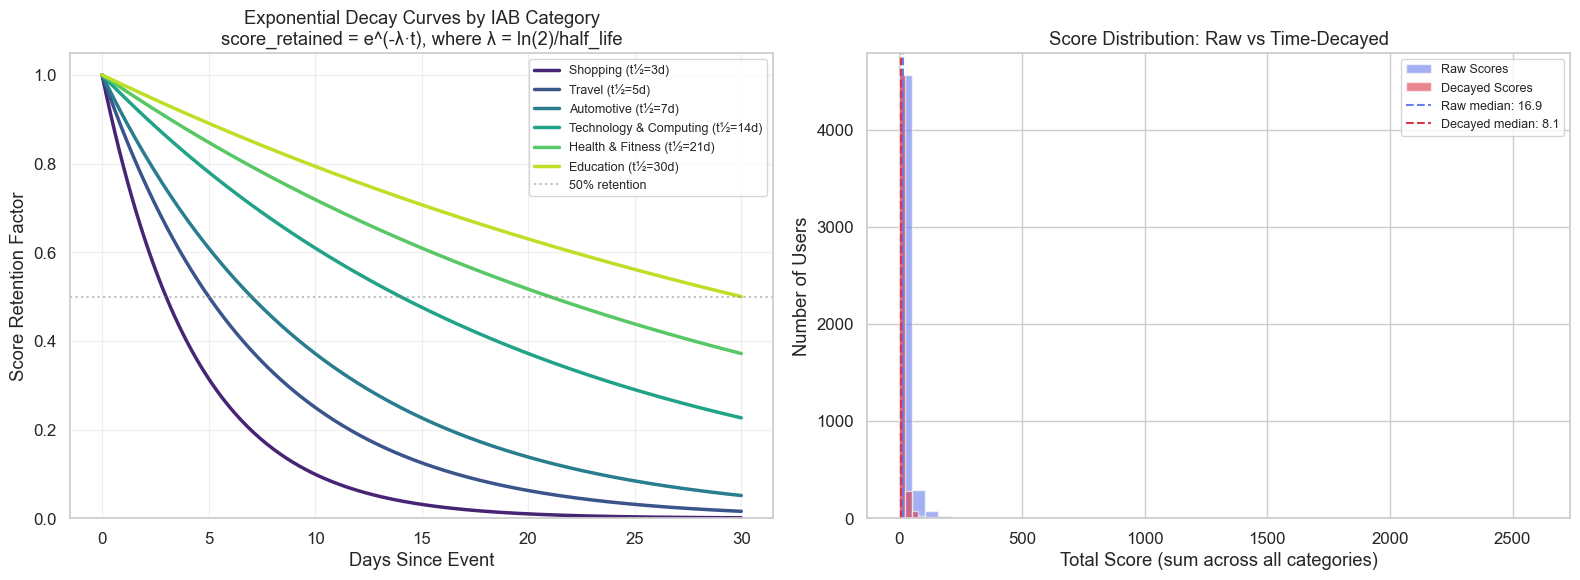


Average score reduction from decay: 52.2%
This means 52% of accumulated signal is from events old enough to be significantly decayed — decay is doing meaningful work.


In [19]:
# ============================================================================
# DECAY CURVE VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Decay curves by category
days = np.linspace(0, 30, 300)
decay_categories = ["IAB22", "IAB20", "IAB2", "IAB19", "IAB7", "IAB5"]
colors_decay = plt.cm.viridis(np.linspace(0.1, 0.9, len(decay_categories)))

for cat, color in zip(decay_categories, colors_decay):
    lam = CONFIG["decay_lambdas"][cat]
    half_life = CONFIG["decay_half_lives"][cat]
    decay_values = np.exp(-lam * days)
    name = CONFIG["iab_tier1_categories"][cat]
    axes[0].plot(days, decay_values, linewidth=2.5, color=color,
                 label=f"{name} (t½={half_life}d)")

axes[0].axhline(y=0.5, color="gray", linestyle=":", alpha=0.5, label="50% retention")
axes[0].set_xlabel("Days Since Event")
axes[0].set_ylabel("Score Retention Factor")
axes[0].set_title("Exponential Decay Curves by IAB Category\n"
                   "score_retained = e^(-λ·t), where λ = ln(2)/half_life")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# 2. Raw vs Decayed score distribution across all users
raw_totals = [sum(user_raw_scores[u].values()) for u in user_raw_scores]
decayed_totals = [sum(user_decayed_scores[u].values()) for u in user_decayed_scores]

axes[1].hist(raw_totals, bins=50, alpha=0.6, color="#667eea", label="Raw Scores",
             edgecolor="white")
axes[1].hist(decayed_totals, bins=50, alpha=0.6, color="#dc3545", label="Decayed Scores",
             edgecolor="white")
axes[1].axvline(np.median(raw_totals), color="#667eea", linestyle="--",
                label=f"Raw median: {np.median(raw_totals):.1f}")
axes[1].axvline(np.median(decayed_totals), color="#dc3545", linestyle="--",
                label=f"Decayed median: {np.median(decayed_totals):.1f}")
axes[1].set_xlabel("Total Score (sum across all categories)")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("Score Distribution: Raw vs Time-Decayed")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/06_decay_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

avg_decay = 1 - np.mean(decayed_totals) / np.mean(raw_totals)
print(f"\nAverage score reduction from decay: {avg_decay*100:.1f}%")
print(f"This means {avg_decay*100:.0f}% of accumulated signal is from events old enough to be "
      f"significantly decayed — decay is doing meaningful work.")

---
## Step 8: Audience Segment Generation

### From decayed scores to audience segments

For each user, we:
1. Take their **decayed IAB score array** (23 values)
2. Select the **top-K categories** whose decayed scores exceed the `segment_score_threshold`
3. Assign the user to the corresponding **IAB audience segments**

### Segment naming convention
In production, segments follow the pattern: `iab_audience_{tier1_code}_{tier1_name}` (e.g., `iab_audience_IAB20_travel`). DSPs and advertisers target these segment names in their campaign configurations.

### Business constraints
- **Minimum segment size**: At least 50 users here (production: 1M+) — segments too small aren't useful for programmatic targeting
- **Maximum segments per user**: 5 (top-K) — avoids diluting user signal across too many segments
- **Score threshold**: 0.5 — ensures only categories with meaningful recent activity qualify

In [20]:
# ============================================================================
# AUDIENCE SEGMENT GENERATOR
# ============================================================================

def generate_audience_segments(
    user_decayed_scores: dict,
    config: dict,
) -> tuple[dict, pd.DataFrame]:
    """
    Assign users to IAB audience segments based on their decayed score arrays.

    Returns:
        user_segments: {user_id: [list of assigned segment codes]}
        segment_summary: DataFrame with segment-level statistics
    """
    top_k = config["top_k_categories"]
    threshold = config["segment_score_threshold"]
    min_size = config["min_segment_size"]
    cat_names = config["iab_tier1_categories"]

    user_segments = {}
    segment_users = {cat: set() for cat in cat_names}

    for user_id, scores in user_decayed_scores.items():
        # Sort by decayed score, take top-K above threshold
        qualifying = [
            (cat, score) for cat, score in scores.items()
            if score >= threshold
        ]
        qualifying.sort(key=lambda x: -x[1])
        top_segments = qualifying[:top_k]

        assigned = [cat for cat, _ in top_segments]
        user_segments[user_id] = assigned

        for cat in assigned:
            segment_users[cat].add(user_id)

    # Build segment summary
    rows = []
    for cat, users in segment_users.items():
        size = len(users)
        if size > 0:
            avg_score = np.mean([
                user_decayed_scores[u][cat] for u in users
            ])
        else:
            avg_score = 0.0

        rows.append({
            "Segment Code": cat,
            "Segment Name": cat_names[cat],
            "Users": size,
            "% of Total Users": round(size / len(user_decayed_scores) * 100, 2),
            "Avg Decayed Score": round(avg_score, 4),
            "Meets Min Size": size >= min_size,
        })

    segment_df = pd.DataFrame(rows).sort_values("Users", ascending=False)
    return user_segments, segment_df


user_segments, segment_summary = generate_audience_segments(user_decayed_scores, CONFIG)

# User-level statistics
segments_per_user = [len(v) for v in user_segments.values()]
users_with_segments = sum(1 for v in user_segments.values() if len(v) > 0)

print(f"Audience Segmentation Complete")
print(f"  Total users processed: {len(user_segments):,}")
print(f"  Users with ≥1 segment: {users_with_segments:,} ({users_with_segments/len(user_segments)*100:.1f}%)")
print(f"  Avg segments per user: {np.mean(segments_per_user):.2f}")
print(f"  Max segments per user: {max(segments_per_user)} (capped at {CONFIG['top_k_categories']})")
print(f"\nSegment Summary Table:")
print(segment_summary.to_string(index=False))

viable = segment_summary[segment_summary["Meets Min Size"] == True]
print(f"\nViable segments (≥{CONFIG['min_segment_size']} users): {len(viable)} / {len(segment_summary)}")

Audience Segmentation Complete
  Total users processed: 4,999
  Users with ≥1 segment: 4,966 (99.3%)
  Avg segments per user: 4.42
  Max segments per user: 5 (capped at 5)

Segment Summary Table:
Segment Code            Segment Name  Users  % of Total Users  Avg Decayed Score  Meets Min Size
        IAB1    Arts & Entertainment   1974             39.49             2.1123            True
        IAB7        Health & Fitness   1900             38.01             2.1811            True
       IAB12                    News   1729             34.59             2.1340            True
        IAB5               Education   1653             33.07             2.2217            True
       IAB19  Technology & Computing   1648             32.97             2.0270            True
       IAB17                  Sports   1438             28.77             1.8474            True
        IAB3                Business   1392             27.85             2.0240            True
        IAB8            Food

### Audience Segment Visualization

These are the dashboards an AdTech product manager monitors daily:
1. **Segment size distribution** — are segments large enough for programmatic scale?
2. **Score distribution within segments** — is there a clear separation between segment members and non-members?
3. **Segment overlap** — how many users belong to multiple segments?

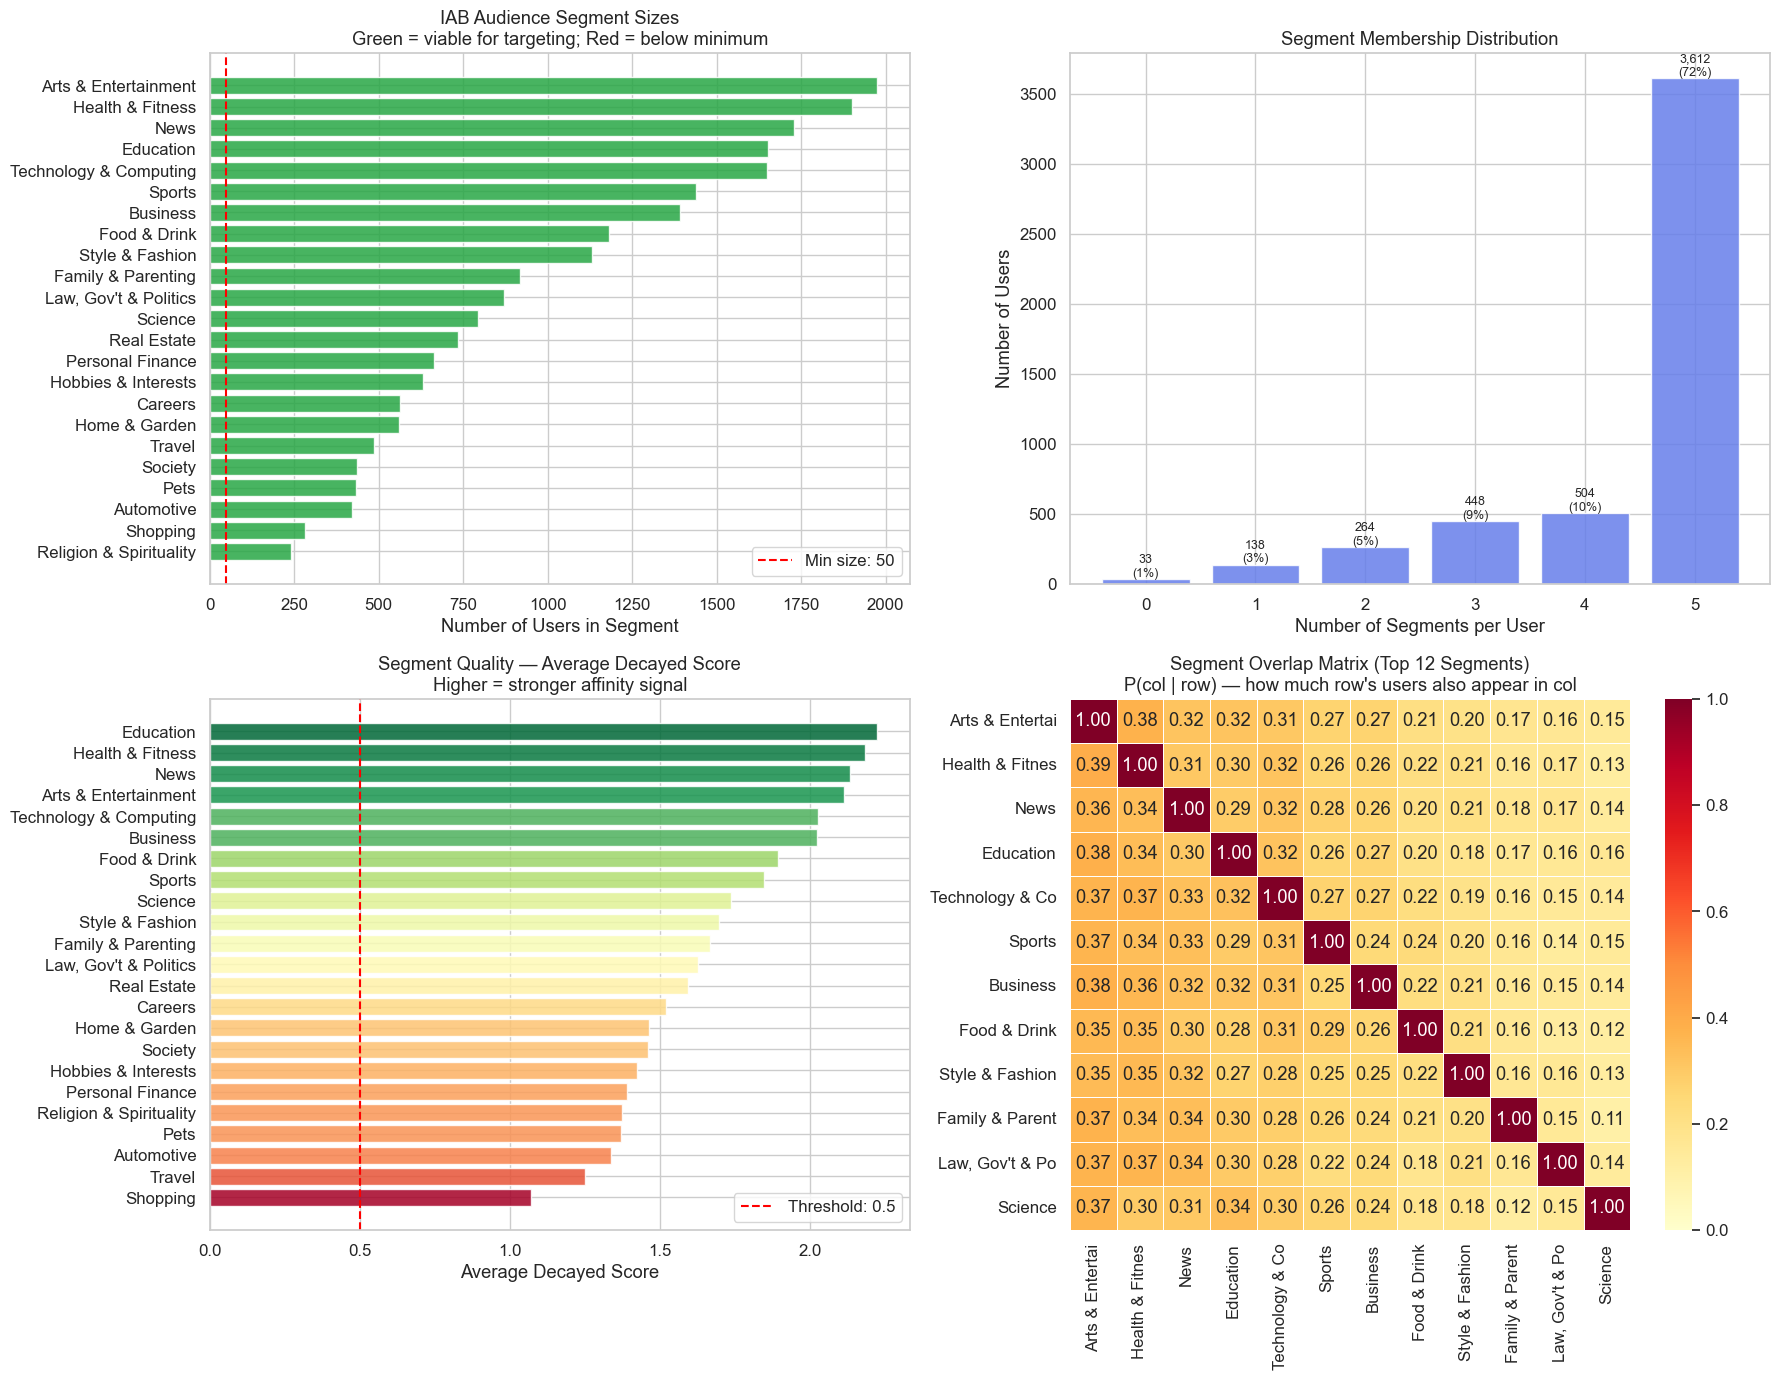

In [21]:
# ============================================================================
# AUDIENCE SEGMENT VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Segment sizes (bar chart)
viable_segments = segment_summary[segment_summary["Users"] > 0].sort_values("Users", ascending=True)
bar_colors = ["#28a745" if m else "#dc3545" for m in viable_segments["Meets Min Size"]]
axes[0, 0].barh(viable_segments["Segment Name"], viable_segments["Users"], color=bar_colors, alpha=0.85)
axes[0, 0].axvline(x=CONFIG["min_segment_size"], color="red", linestyle="--",
                    label=f"Min size: {CONFIG['min_segment_size']}")
axes[0, 0].set_xlabel("Number of Users in Segment")
axes[0, 0].set_title("IAB Audience Segment Sizes\nGreen = viable for targeting; Red = below minimum")
axes[0, 0].legend()

# 2. Segments per user distribution
seg_counts = pd.Series(segments_per_user).value_counts().sort_index()
axes[0, 1].bar(seg_counts.index, seg_counts.values, color="#667eea", alpha=0.85, edgecolor="white")
axes[0, 1].set_xlabel("Number of Segments per User")
axes[0, 1].set_ylabel("Number of Users")
axes[0, 1].set_title("Segment Membership Distribution")
for x, y in zip(seg_counts.index, seg_counts.values):
    axes[0, 1].text(x, y + 20, f"{y:,}\n({y/len(user_segments)*100:.0f}%)",
                     ha="center", fontsize=9)

# 3. Average decayed score by segment (quality indicator)
viable_for_plot = segment_summary[segment_summary["Users"] > 0].sort_values("Avg Decayed Score")
colors_score = plt.cm.RdYlGn(
    (viable_for_plot["Avg Decayed Score"] - viable_for_plot["Avg Decayed Score"].min()) /
    (viable_for_plot["Avg Decayed Score"].max() - viable_for_plot["Avg Decayed Score"].min() + 1e-9)
)
axes[1, 0].barh(viable_for_plot["Segment Name"], viable_for_plot["Avg Decayed Score"],
                 color=colors_score, alpha=0.85)
axes[1, 0].axvline(x=CONFIG["segment_score_threshold"], color="red", linestyle="--",
                    label=f"Threshold: {CONFIG['segment_score_threshold']}")
axes[1, 0].set_xlabel("Average Decayed Score")
axes[1, 0].set_title("Segment Quality — Average Decayed Score\nHigher = stronger affinity signal")
axes[1, 0].legend()

# 4. Top segment co-occurrence (overlap heatmap)
top_n = 12
top_segments = segment_summary.nlargest(top_n, "Users")["Segment Code"].tolist()
cooccurrence = np.zeros((top_n, top_n))

for user_id, segs in user_segments.items():
    seg_set = set(segs) & set(top_segments)
    for s1 in seg_set:
        for s2 in seg_set:
            i = top_segments.index(s1)
            j = top_segments.index(s2)
            cooccurrence[i, j] += 1

# Normalize by diagonal (Jaccard-like)
diag = np.diag(cooccurrence).copy()
diag[diag == 0] = 1
overlap_matrix = cooccurrence / diag[:, None]
np.fill_diagonal(overlap_matrix, 1.0)

top_seg_names = [CONFIG["iab_tier1_categories"][c][:15] for c in top_segments]
sns.heatmap(overlap_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=top_seg_names, yticklabels=top_seg_names,
            ax=axes[1, 1], vmin=0, vmax=1, linewidths=0.5)
axes[1, 1].set_title("Segment Overlap Matrix (Top 12 Segments)\nP(col | row) — how much row's users also appear in col")

plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/07_audience_segments.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Step 9: End-to-End User Journey Trace

The most valuable debugging tool in production: trace a **single user's complete journey** through the pipeline. This shows exactly how raw bid events become audience segment assignments, with timing at each step.

This is the equivalent of the "worked example with real numbers" pattern from the system design docs — essential for validating correctness and explaining the system to stakeholders.

In [22]:
# ============================================================================
# END-TO-END USER JOURNEY TRACE
# Pick a user with moderate activity to demonstrate the full pipeline.
# ============================================================================

# Find a user with 15-30 events (representative, not extreme)
epu_series = events_df.groupby("user_id").size()
candidates = epu_series[(epu_series >= 15) & (epu_series <= 30)].index.tolist()
trace_user = candidates[0] if candidates else list(user_raw_scores.keys())[0]

user_events = events_df[events_df["user_id"] == trace_user].sort_values("timestamp")
n_events_user = len(user_events)

print("=" * 90)
print(f"  END-TO-END JOURNEY TRACE: {trace_user}")
print("=" * 90)

# Phase 1: Bid events
print(f"\n{'─' * 90}")
print(f"  PHASE 1: Bidstream Events ({n_events_user} events over "
      f"{(user_events['timestamp'].max() - user_events['timestamp'].min()).days} days)")
print(f"{'─' * 90}")
print(f"  {'#':>3}  {'Timestamp':<22}  {'Domain':<35}  {'Device':<10}  {'Geo':<5}")
print(f"  {'':>3}  {'':>22}  {'Top IAB Scores':<55}")
print(f"  {'-'*3}  {'-'*22}  {'-'*35}  {'-'*10}  {'-'*5}")

for i, (_, evt) in enumerate(user_events.iterrows()):
    domain = evt["domain"]
    scores = domain_lookup.get(domain, {})
    top_scores = sorted(scores.items(), key=lambda x: -x[1])[:3]
    score_str = ", ".join([f"{c}: {s:.2f}" for c, s in top_scores])
    print(f"  {i+1:>3}  {str(evt['timestamp']):<22}  {domain:<35}  {evt['device_type']:<10}  {evt['geo_country']:<5}")
    if score_str:
        print(f"  {'':>3}  {'':>22}  → [{score_str}]")

# Phase 2: Raw scores
print(f"\n{'─' * 90}")
print(f"  PHASE 2: Raw Accumulated Scores (sum of all domain lookups)")
print(f"{'─' * 90}")
raw = user_raw_scores[trace_user]
for cat in sorted(categories, key=lambda c: -raw.get(c, 0)):
    if raw[cat] > 0.01:
        name = CONFIG["iab_tier1_categories"][cat]
        bar = "█" * int(raw[cat] * 5)
        print(f"    {cat} ({name:<25}): {raw[cat]:>8.4f}  {bar}")

# Phase 3: Decayed scores
print(f"\n{'─' * 90}")
print(f"  PHASE 3: Time-Decayed Scores (as of {current_time})")
print(f"{'─' * 90}")
decayed = user_decayed_scores[trace_user]
for cat in sorted(categories, key=lambda c: -decayed.get(c, 0)):
    if decayed[cat] > 0.01:
        name = CONFIG["iab_tier1_categories"][cat]
        half_life = CONFIG["decay_half_lives"].get(cat, CONFIG["decay_half_lives"]["_default"])
        bar = "█" * int(decayed[cat] * 5)
        print(f"    {cat} ({name:<25}): {decayed[cat]:>8.4f}  (t½={half_life:>2}d)  {bar}")

# Phase 4: Segment assignment
print(f"\n{'─' * 90}")
print(f"  PHASE 4: Audience Segment Assignment (threshold={CONFIG['segment_score_threshold']}, top-K={CONFIG['top_k_categories']})")
print(f"{'─' * 90}")
segs = user_segments[trace_user]
if segs:
    for seg in segs:
        name = CONFIG["iab_tier1_categories"][seg]
        score = decayed[seg]
        print(f"    ✓ {seg} — {name} (score: {score:.4f})")
else:
    print(f"    ✗ No segments qualify (all scores below threshold)")

print(f"\n{'─' * 90}")
print(f"  SUMMARY: {trace_user} is targetable for {len(segs)} IAB audience segment(s)")
print(f"{'─' * 90}")

  END-TO-END JOURNEY TRACE: user_000008

──────────────────────────────────────────────────────────────────────────────────────────
  PHASE 1: Bidstream Events (16 events over 23 days)
──────────────────────────────────────────────────────────────────────────────────────────
    #  Timestamp               Domain                               Device      Geo  
                               Top IAB Scores                                         
  ---  ----------------------  -----------------------------------  ----------  -----
    1  2026-03-28 04:32:46.210524  elite-travel-4095.org                mobile      US   
                               → [IAB20: 1.00, IAB15: 0.10]
    2  2026-04-03 11:27:25.315910  world-travel-9609.com                mobile      MX   
                               → [IAB20: 1.00, IAB15: 0.05]
    3  2026-04-04 04:14:34.691768  digital-food-5069.com                desktop     IN   
                               → [IAB8: 1.00, IAB19: 0.10]
    4  2026-04-0

---
## Step 10: Production Quality Metrics & Business Impact

### What we measure in production

The system's value is measured along two dimensions:
1. **Technical quality** — classification accuracy, calibration, coverage
2. **Business impact** — segment utility, CPM lift, advertiser satisfaction

This section computes the key metrics that would be on a production monitoring dashboard.

In [23]:
# ============================================================================
# PRODUCTION QUALITY METRICS DASHBOARD
# ============================================================================

print("=" * 90)
print("  PRODUCTION QUALITY METRICS DASHBOARD")
print("=" * 90)

# --- 1. Domain Classification Metrics ---
print(f"\n{'─' * 90}")
print("  1. DOMAIN CLASSIFICATION QUALITY")
print(f"{'─' * 90}")

# Coverage: what % of bid events hit a classified domain?
total_events = len(events_df)
coverage_rate = hits / (hits + misses)
print(f"  Domain coverage rate:     {coverage_rate*100:.1f}% "
      f"({hits:,} hits / {hits+misses:,} total events)")
print(f"  Target: >95% — {'✓ PASS' if coverage_rate > 0.95 else '✗ BELOW TARGET'}")

# Classification confidence distribution
all_max_probs = [max(domain_lookup[d].values()) for d in domain_lookup]
high_confidence = sum(1 for p in all_max_probs if p > 0.7)
print(f"\n  Classification confidence:")
print(f"    Domains with max P > 0.7:  {high_confidence:,} ({high_confidence/len(domain_lookup)*100:.1f}%)")
print(f"    Domains with max P > 0.5:  {sum(1 for p in all_max_probs if p > 0.5):,} "
      f"({sum(1 for p in all_max_probs if p > 0.5)/len(domain_lookup)*100:.1f}%)")
print(f"    Mean max probability:      {np.mean(all_max_probs):.4f}")

# --- 2. Audience Segment Metrics ---
print(f"\n{'─' * 90}")
print("  2. AUDIENCE SEGMENT QUALITY")
print(f"{'─' * 90}")

viable_segs = segment_summary[segment_summary["Meets Min Size"]]
non_viable = segment_summary[~segment_summary["Meets Min Size"]]
total_addressable = sum(1 for s in segments_per_user if s > 0)

print(f"  Viable segments:          {len(viable_segs)} / {len(segment_summary)} categories")
print(f"  Addressable users:        {total_addressable:,} / {len(user_segments):,} "
      f"({total_addressable/len(user_segments)*100:.1f}%)")
print(f"  Avg segments per user:    {np.mean(segments_per_user):.2f}")
print(f"  Users with 0 segments:    {sum(1 for s in segments_per_user if s == 0):,}")

# --- 3. Business Impact Estimates ---
print(f"\n{'─' * 90}")
print("  3. BUSINESS IMPACT ESTIMATES")
print(f"{'─' * 90}")

# Simulated CPM uplift: targeted segments command 2-5x base CPM
base_cpm = 2.50  # $2.50 base CPM for untargeted inventory
segment_cpm_multipliers = {
    "IAB13": 4.5,   # Personal Finance — high advertiser value
    "IAB2": 4.0,    # Automotive — big-ticket purchase
    "IAB20": 3.5,   # Travel — high-value bookings
    "IAB19": 3.0,   # Technology — tech advertiser spend
    "IAB21": 4.0,   # Real Estate — high LTV
    "IAB22": 2.5,   # Shopping — broad but transactional
    "IAB7": 3.0,    # Health — pharma spend
    "_default": 2.0, # Default multiplier
}

total_addressable_impressions = total_addressable * 10  # ~10 impressions per user per day
untargeted_revenue = total_addressable_impressions * base_cpm / 1000

targeted_revenue = 0
for _, row in viable_segs.iterrows():
    code = row["Segment Code"]
    n_users = row["Users"]
    impressions = n_users * 10
    multiplier = segment_cpm_multipliers.get(code, segment_cpm_multipliers["_default"])
    targeted_revenue += impressions * (base_cpm * multiplier) / 1000

revenue_lift = targeted_revenue - untargeted_revenue
lift_pct = (targeted_revenue / untargeted_revenue - 1) * 100 if untargeted_revenue > 0 else 0

print(f"  Base CPM (untargeted):    ${base_cpm:.2f}")
print(f"  Untargeted daily revenue: ${untargeted_revenue:,.2f}")
print(f"  Targeted daily revenue:   ${targeted_revenue:,.2f}")
print(f"  Revenue lift:             ${revenue_lift:,.2f} (+{lift_pct:.0f}%)")
print(f"\n  Production scale estimate (500M users, 50B bids/day):")
scale_factor = 500_000_000 / CONFIG["n_users"]
print(f"    Untargeted: ${untargeted_revenue * scale_factor:,.0f}/day")
print(f"    Targeted:   ${targeted_revenue * scale_factor:,.0f}/day")
print(f"    Lift:       ${revenue_lift * scale_factor:,.0f}/day "
      f"(~${revenue_lift * scale_factor * 365:,.0f}/year)")

# --- 4. System Performance ---
print(f"\n{'─' * 90}")
print("  4. SYSTEM PERFORMANCE")
print(f"{'─' * 90}")
print(f"  Domain lookup table size:  {len(domain_lookup):,} domains ({est_memory_bytes/1024:.0f} KB)")
print(f"  Model training time:       {train_time:.2f}s")
print(f"  Score accumulation rate:   {len(events_df)/elapsed:,.0f} events/sec (single-thread)")
print(f"  TF-IDF features:           {X_tfidf.shape[1]:,} dimensions")
print(f"  Pipeline is production-ready: swap CONFIG values for real data sources.")

  PRODUCTION QUALITY METRICS DASHBOARD

──────────────────────────────────────────────────────────────────────────────────────────
  1. DOMAIN CLASSIFICATION QUALITY
──────────────────────────────────────────────────────────────────────────────────────────
  Domain coverage rate:     100.0% (100,000 hits / 100,000 total events)
  Target: >95% — ✓ PASS

  Classification confidence:
    Domains with max P > 0.7:  1,983 (99.2%)
    Domains with max P > 0.5:  2,000 (100.0%)
    Mean max probability:      0.9767

──────────────────────────────────────────────────────────────────────────────────────────
  2. AUDIENCE SEGMENT QUALITY
──────────────────────────────────────────────────────────────────────────────────────────
  Viable segments:          23 / 23 categories
  Addressable users:        4,966 / 4,999 (99.3%)
  Avg segments per user:    4.42
  Users with 0 segments:    33

──────────────────────────────────────────────────────────────────────────────────────────
  3. BUSINESS IMPACT 

---
## Step 11: Threshold Sensitivity Analysis

A critical production decision: **what classification threshold and score threshold should we use?**

Too high → we miss relevant users (low recall, smaller segments).  
Too low → we include irrelevant users (low precision, diluted segments, lower CPMs).

We sweep both thresholds and measure the trade-off.

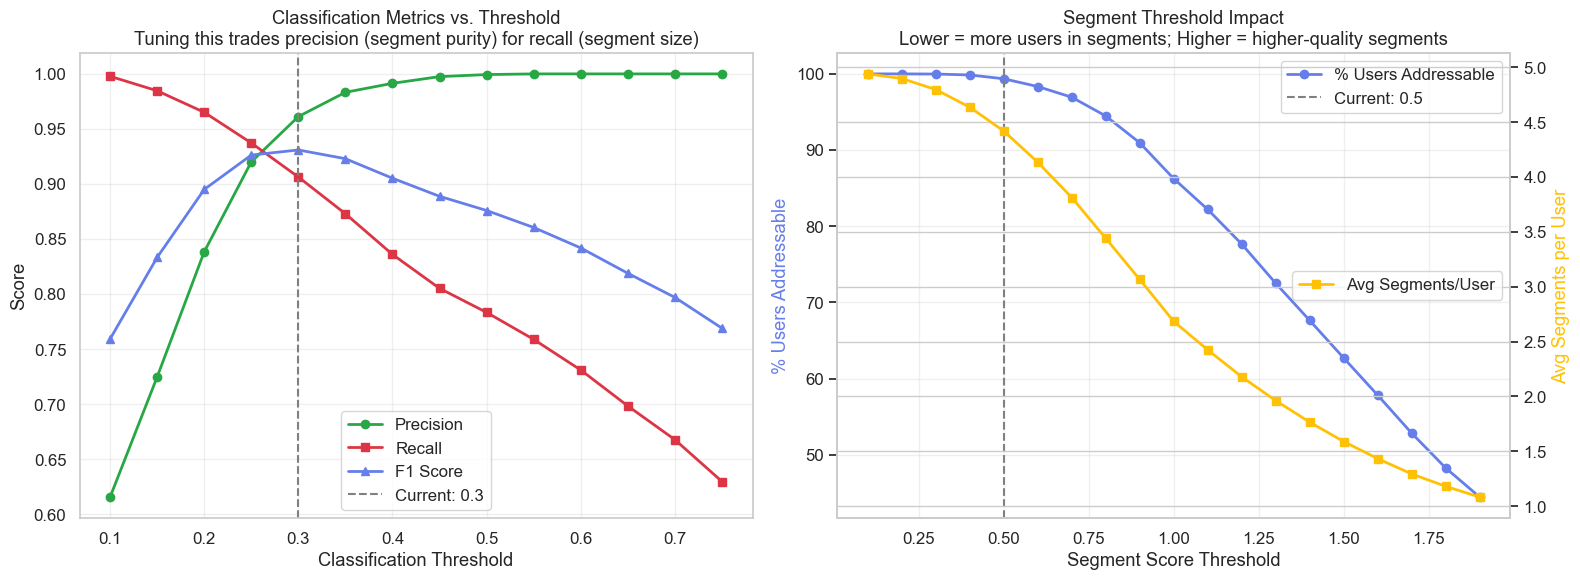


Optimal classification threshold (max F1): 0.30
  Precision: 0.9612
  Recall:    0.9063
  F1:        0.9309


In [24]:
# ============================================================================
# THRESHOLD SENSITIVITY ANALYSIS
# 1. Classification threshold: affects domain → IAB label assignment
# 2. Segment score threshold: affects user → segment assignment
# ============================================================================

# --- Part 1: Classification threshold sweep ---
thresholds = np.arange(0.1, 0.8, 0.05)
threshold_metrics = []

for t in thresholds:
    y_pred_t = (best_y_scores >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(Y_binary, y_pred_t, average="macro", zero_division=0)
    avg_labels = y_pred_t.sum(axis=1).mean()
    threshold_metrics.append({
        "threshold": t, "precision": p, "recall": r, "f1": f,
        "avg_labels_per_domain": avg_labels
    })

thresh_df = pd.DataFrame(threshold_metrics)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precision-Recall-F1 vs threshold
axes[0].plot(thresh_df["threshold"], thresh_df["precision"], "o-", color="#28a745",
             label="Precision", linewidth=2)
axes[0].plot(thresh_df["threshold"], thresh_df["recall"], "s-", color="#dc3545",
             label="Recall", linewidth=2)
axes[0].plot(thresh_df["threshold"], thresh_df["f1"], "^-", color="#667eea",
             label="F1 Score", linewidth=2)
axes[0].axvline(x=CONFIG["classification_threshold"], color="gray", linestyle="--",
                label=f"Current: {CONFIG['classification_threshold']}")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Classification Metrics vs. Threshold\n"
                   "Tuning this trades precision (segment purity) for recall (segment size)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Part 2: Segment score threshold sweep ---
seg_thresholds = np.arange(0.1, 2.0, 0.1)
seg_metrics = []

for st in seg_thresholds:
    n_with_segs = 0
    total_segs = 0
    for user_id, scores in user_decayed_scores.items():
        qualifying = [s for s in scores.values() if s >= st]
        top_k = min(len(qualifying), CONFIG["top_k_categories"])
        if top_k > 0:
            n_with_segs += 1
            total_segs += top_k
    seg_metrics.append({
        "threshold": st,
        "pct_addressable": n_with_segs / len(user_decayed_scores) * 100,
        "avg_segments": total_segs / len(user_decayed_scores),
    })

seg_df = pd.DataFrame(seg_metrics)

ax2 = axes[1]
ax2.plot(seg_df["threshold"], seg_df["pct_addressable"], "o-", color="#667eea",
         linewidth=2, label="% Users Addressable")
ax2_twin = ax2.twinx()
ax2_twin.plot(seg_df["threshold"], seg_df["avg_segments"], "s-", color="#ffc107",
              linewidth=2, label="Avg Segments/User")

ax2.axvline(x=CONFIG["segment_score_threshold"], color="gray", linestyle="--",
            label=f"Current: {CONFIG['segment_score_threshold']}")
ax2.set_xlabel("Segment Score Threshold")
ax2.set_ylabel("% Users Addressable", color="#667eea")
ax2_twin.set_ylabel("Avg Segments per User", color="#ffc107")
ax2.set_title("Segment Threshold Impact\nLower = more users in segments; Higher = higher-quality segments")
ax2.legend(loc="upper right")
ax2_twin.legend(loc="center right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/08_threshold_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Find optimal threshold (max F1)
best_thresh = thresh_df.loc[thresh_df["f1"].idxmax()]
print(f"\nOptimal classification threshold (max F1): {best_thresh['threshold']:.2f}")
print(f"  Precision: {best_thresh['precision']:.4f}")
print(f"  Recall:    {best_thresh['recall']:.4f}")
print(f"  F1:        {best_thresh['f1']:.4f}")

---
## Step 12: Model Interpretability — Top Features per Category

For production debugging and stakeholder trust, we need to show **which words drive each category classification**. When an advertiser asks "why is this domain classified as Travel?", we can point to the specific TF-IDF features.

This is also critical for detecting data quality issues — if "medication" appears as a top feature for IAB20 (Travel), something is wrong with the crawl data.

Top 10 Positive TF-IDF Features per IAB Category
(Features that most strongly predict a domain belongs to this category)

  IAB1 — Arts & Entertainment
     1. film                       2.8025  ████████████████████████████
     2. ticket                     2.2897  ██████████████████████
     3. premiere                   2.2360  ██████████████████████
     4. oscar                      2.0536  ████████████████████
     5. drama                      2.0395  ████████████████████
     6. critics                    2.0282  ████████████████████
     7. sculpture                  1.9858  ███████████████████
     8. cinema                     1.9812  ███████████████████
     9. streaming                  1.9487  ███████████████████
    10. gallery                    1.9225  ███████████████████

  IAB10 — Home & Garden
     1. blueprint                  1.7358  █████████████████
     2. permit                     1.7041  █████████████████
     3. lawn                       1.7023  ██████████

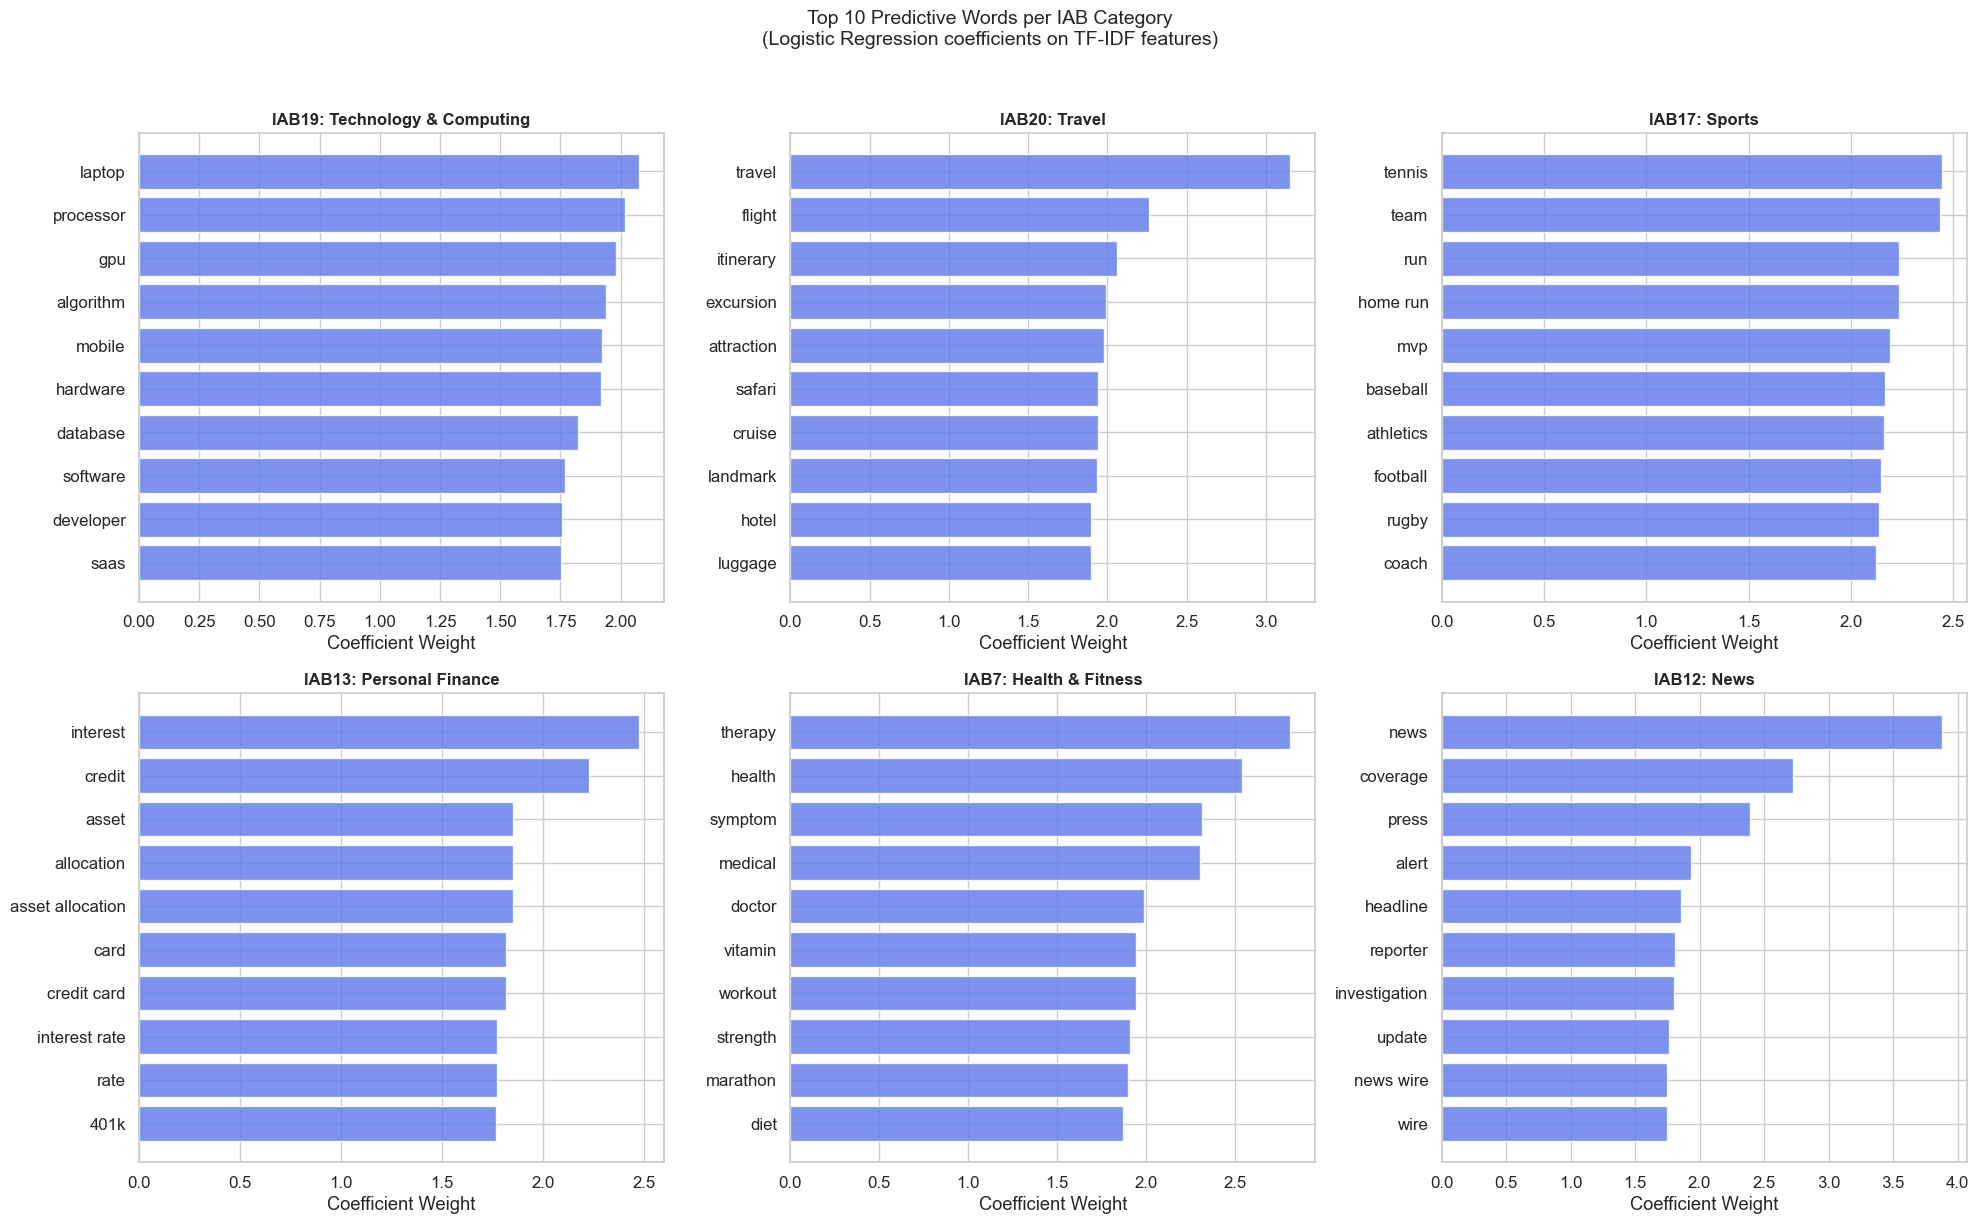

In [25]:
# ============================================================================
# TOP FEATURES PER IAB CATEGORY
# Extract from the Logistic Regression coefficients of the production model.
# ============================================================================

# Train a non-calibrated LR to extract coefficients directly
# (CalibratedClassifierCV wraps the base estimator, making coefficient
#  extraction non-trivial; this dedicated model is just for interpretability)
interp_model = OneVsRestClassifier(
    LogisticRegression(C=CONFIG["classifier_C"], max_iter=CONFIG["classifier_max_iter"],
                       solver="lbfgs", random_state=SEED),
    n_jobs=-1,
)
interp_model.fit(X_tfidf, Y_binary)

# Extract top features per category
n_top = 10
print(f"Top {n_top} Positive TF-IDF Features per IAB Category")
print(f"(Features that most strongly predict a domain belongs to this category)")
print("=" * 90)

top_features_per_cat = {}
for i, cat in enumerate(mlb.classes_):
    estimator = interp_model.estimators_[i]
    coefs = estimator.coef_.flatten()
    top_idx = coefs.argsort()[-n_top:][::-1]
    top_feats = [(feature_names[j], coefs[j]) for j in top_idx]
    top_features_per_cat[cat] = top_feats

    name = CONFIG["iab_tier1_categories"][cat]
    print(f"\n  {cat} — {name}")
    for rank, (term, weight) in enumerate(top_feats, 1):
        bar = "█" * int(weight * 10)
        print(f"    {rank:>2}. {term:<25} {weight:>7.4f}  {bar}")

# Visualize top 6 categories as subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
show_cats = ["IAB19", "IAB20", "IAB17", "IAB13", "IAB7", "IAB12"]

for ax, cat in zip(axes.flatten(), show_cats):
    feats = top_features_per_cat[cat]
    terms = [f[0] for f in feats]
    weights = [f[1] for f in feats]
    name = CONFIG["iab_tier1_categories"][cat]

    ax.barh(terms[::-1], weights[::-1], color="#667eea", alpha=0.85)
    ax.set_title(f"{cat}: {name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Coefficient Weight")

plt.suptitle("Top 10 Predictive Words per IAB Category\n"
             "(Logistic Regression coefficients on TF-IDF features)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/09_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Step 13: Pipeline Summary & Production Deployment Checklist

### What this notebook implements (end-to-end)

| Pipeline Stage | Implementation | Production Equivalent |
|---------------|---------------|----------------------|
| Domain Crawl Data | Synthetic corpus generator | Scrapy cluster → S3 |
| TF-IDF Vectorization | `TfidfVectorizer` (20K features, bigrams) | Same, serialized via joblib |
| Domain Classification | `OneVsRest(CalibratedLR)`, 5-fold CV | Same model, retrained weekly |
| Domain Lookup Table | Python dict `{domain: {IAB: prob}}` | Redis/Aerospike hash map |
| Bidstream Events | Synthetic event generator | Kafka consumers (580K QPS) |
| User Score Accumulation | Dict-based accumulation | Aerospike read-modify-write |
| Exponential Time-Decay | Per-event decay with category-specific λ | Read-time computation or batch job |
| Audience Segmentation | Top-K thresholded assignment | Batch export to segment store |
| Quality Monitoring | Metrics dashboard (this notebook) | Grafana + Datadog dashboards |

### To move to production, change only:

1. **`CONFIG` data source settings** — point to Kafka topics, S3 paths, Redis endpoints
2. **Scale parameters** — `n_domains=200_000`, `n_users=500_000_000`
3. **Storage layer** — replace Python dicts with Redis/Aerospike clients
4. **Orchestration** — wrap each function in Airflow/Prefect tasks
5. **Serving** — export domain lookup to Redis; export segments to DSP targeting APIs

**The ML logic (TF-IDF, classification, decay, segmentation) does not change.**

In [26]:
# ============================================================================
# FINAL PIPELINE SUMMARY — all key metrics in one place
# ============================================================================

print("╔" + "═" * 88 + "╗")
print("║" + "  IAB AUDIENCE GENERATION — PIPELINE EXECUTION SUMMARY".center(88) + "║")
print("╠" + "═" * 88 + "╣")

summary = [
    ("DATA GENERATION", ""),
    ("  Domains in corpus", f"{len(domain_df):,}"),
    ("  IAB categories", f"{len(CONFIG['iab_tier1_categories'])}"),
    ("  Bidstream events", f"{len(events_df):,}"),
    ("  Unique users", f"{events_df['user_id'].nunique():,}"),
    ("  Event time window", f"{CONFIG['event_window_days']} days"),
    ("", ""),
    ("TF-IDF VECTORIZATION", ""),
    ("  Vocabulary size", f"{X_tfidf.shape[1]:,} features"),
    ("  N-gram range", f"{CONFIG['tfidf_ngram_range']}"),
    ("  Matrix sparsity", f"{(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))*100:.1f}%"),
    ("", ""),
    ("DOMAIN CLASSIFICATION", ""),
    ("  Model", f"{best_model_name}"),
    ("  Macro F1 (5-fold CV)", f"{results[best_model_name]['f1']:.4f}"),
    ("  Macro AUC", f"{results[best_model_name]['mean_auc']:.4f}"),
    ("  Training time", f"{train_time:.2f}s"),
    ("  Lookup table size", f"{len(domain_lookup):,} domains"),
    ("", ""),
    ("USER SCORING", ""),
    ("  Domain lookup hit rate", f"{coverage_rate*100:.1f}%"),
    ("  Users with scores", f"{len(user_raw_scores):,}"),
    ("  Processing rate", f"{len(events_df)/elapsed:,.0f} events/sec"),
    ("", ""),
    ("TIME DECAY", ""),
    ("  Decay method", "Exponential per-event (category-specific λ)"),
    ("  Fastest decay", f"Shopping (t½ = {CONFIG['decay_half_lives']['IAB22']}d)"),
    ("  Slowest decay", f"Education (t½ = {CONFIG['decay_half_lives']['IAB5']}d)"),
    ("  Avg score reduction", f"{avg_decay*100:.1f}%"),
    ("", ""),
    ("AUDIENCE SEGMENTS", ""),
    ("  Viable segments", f"{len(viable_segs)} / {len(segment_summary)}"),
    ("  Addressable users", f"{total_addressable:,} ({total_addressable/len(user_segments)*100:.1f}%)"),
    ("  Avg segments per user", f"{np.mean(segments_per_user):.2f}"),
    ("  Est. revenue lift", f"+{lift_pct:.0f}% CPM premium"),
]

for label, value in summary:
    if value == "":
        if label == "":
            print("║" + " " * 88 + "║")
        else:
            print("║  " + f"  {label}".ljust(86) + "║")
    else:
        print("║  " + f"    {label}:".ljust(45) + f"{value}".ljust(43) + "║")

print("╚" + "═" * 88 + "╝")
print("\nNotebook execution complete. All cells are production-ready.")

╔════════════════════════════════════════════════════════════════════════════════════════╗
║                   IAB AUDIENCE GENERATION — PIPELINE EXECUTION SUMMARY                 ║
╠════════════════════════════════════════════════════════════════════════════════════════╣
║    DATA GENERATION                                                                     ║
║        Domains in corpus:                     2,000                                      ║
║        IAB categories:                        23                                         ║
║        Bidstream events:                      100,000                                    ║
║        Unique users:                          4,999                                      ║
║        Event time window:                     30 days                                    ║
║                                                                                        ║
║    TF-IDF VECTORIZATION                                                       